In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128,garbage_collection_threshold:0.8"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # makes errors point to the real line

In [2]:
import sys, subprocess

def pip_install(package, extra_args=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q", package]
    if extra_args:
        cmd += extra_args
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠ FAILED: {package}\n{result.stderr.strip()[-300:]}")
    else:
        print(f"✓ {package}")

packages = [
    "nibabel",
    "nilearn",
    "SimpleITK",
    "torchio",
    "monai",
    "pyreadr",
    "captum",      
    "scikit-learn",
    "scipy",
    "seaborn",
]

for pkg in packages:
    pip_install(pkg)

subprocess.run(["apt-get", "install", "-qq", "-y", "dcm2niix"],
               capture_output=True)
print("✓ dcm2niix")
print("\n✓ All done — restart kernel now before running further cells")

✓ nibabel
✓ nilearn
✓ SimpleITK
✓ torchio
✓ monai
✓ pyreadr
✓ captum
✓ scikit-learn
✓ scipy
✓ seaborn
✓ dcm2niix

✓ All done — restart kernel now before running further cells


In [3]:
import os, glob, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import torchio as tio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR      = "ADNI"
DICOM_DIR     = "ADNI/ADNI_part1_fixed/ADNI/"
DICOM_DIR2    = "ADNI/ADNI_part5_fixed/ADNI/"
ADNIMERGE_CSV = "ADNI/Data___Database/"

NIFTI_DIR = "OUTPUTS/nifti/"
PREP_DIR  = "OUTPUTS/preprocessed/"

os.makedirs(NIFTI_DIR, exist_ok=True)
os.makedirs(PREP_DIR,  exist_ok=True)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.5.1+cu121 | CUDA: True
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [4]:
import random, logging, warnings
from dataclasses import dataclass, field
from typing import List

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

@dataclass
class Config:
    # Data
    target_shape:  tuple = (96, 112, 96)
    n_classes:     int   = 3
    class_names:   List[str] = field(default_factory=lambda: ["CN", "MCI", "AD"])

    # Training
    epochs:        int   = 150
    batch_size:    int   = 8
    lr:            float = 3e-4
    weight_decay:  float = 1e-4
    warmup_epochs: int   = 5
    label_smoothing: float = 0.05
    mixup_alpha:   float = 0.2
    n_folds:       int   = 1
    seed:          int   = 42

    dropout:       float = 0.3
    use_attention: bool  = True

    output_dir:    str   = "OUTPUTS/"

CFG = Config()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(CFG.output_dir + "experiment.log"),
        logging.StreamHandler()
    ]
)
log = logging.getLogger(__name__)
log.info(f"Config: {CFG}")
log.info(f"Device: {DEVICE} | Seed: {SEED}")

2026-05-05 08:41:54,039 | INFO | Config: Config(target_shape=(96, 112, 96), n_classes=3, class_names=['CN', 'MCI', 'AD'], epochs=150, batch_size=8, lr=0.0003, weight_decay=0.0001, warmup_epochs=5, label_smoothing=0.05, mixup_alpha=0.2, n_folds=1, seed=42, dropout=0.3, use_attention=True, output_dir='OUTPUTS/')
2026-05-05 08:41:54,040 | INFO | Device: cuda | Seed: 42


In [5]:
import pyreadr
import pandas as pd
import glob

rda_base = "ADNI/Data___Database/ADNIMERGE2/ADNIMERGE2/data/"

def load_rda(filename):
    result = pyreadr.read_r(rda_base + filename)
    return result[list(result.keys())[0]]

dxsum    = load_rda("DXSUM.rda")
baseline = dxsum[dxsum["VISCODE"] == "bl"].copy()
baseline = baseline.dropna(subset=["DIAGNOSIS"])
dx_map   = {"CN": 0, "MCI": 1, "Dementia": 2, "AD": 2}
baseline["label"] = baseline["DIAGNOSIS"].map(dx_map)
baseline = baseline.dropna(subset=["label"])
baseline["label"] = baseline["label"].astype(int)

ptdemog   = load_rda("PTDEMOG.rda")
ptdemog_u = ptdemog.drop_duplicates("RID")[["RID", "PTGENDER", "PTDOB"]].copy()

def dob_to_age(dob):
    try:
        parts = str(dob).split("/")
        birth_year = int(parts[-1])
        return 2005 - birth_year
    except:
        return float("nan")

ptdemog_u["AGE"] = ptdemog_u["PTDOB"].apply(dob_to_age)
ptdemog_u = ptdemog_u[["RID", "PTGENDER", "AGE"]]

mmse    = load_rda("MMSE.rda")
mmse_bl = mmse[mmse["VISCODE"].isin(["bl", "sc"])].copy() 
mmse_bl = mmse_bl.sort_values("VISCODE")                   
mmse_bl = mmse_bl.drop_duplicates("RID", keep="first")
mmse_bl = mmse_bl[["RID", "MMSCORE"]].copy()           
mmse_bl = mmse_bl.rename(columns={"MMSCORE": "MMSE"})

apoeres = load_rda("APOERES.rda")

def genotype_to_apoe4(genotype):
    """Count number of e4 alleles from string like '3/4' or '4/4'"""
    try:
        alleles = str(genotype).split("/")
        return sum(1 for a in alleles if a.strip() == "4")
    except:
        return float("nan")

apoe_u = apoeres.copy()
apoe_u["APOE4"] = apoe_u["GENOTYPE"].apply(genotype_to_apoe4)
apoe_u = apoe_u.drop_duplicates("RID")[["RID", "APOE4"]].copy()
apoe_u["RID"] = apoe_u["RID"].astype(int)

print("APOE4 distribution:\n", apoe_u["APOE4"].value_counts())
for df in [baseline, ptdemog_u, mmse_bl, apoe_u]:
    df["RID"] = df["RID"].astype(int)

print("\nRID dtype check:")
print("  baseline :", baseline["RID"].dtype,  "| n:", len(baseline))
print("  mmse_bl  :", mmse_bl["RID"].dtype,   "| matches:", mmse_bl["RID"].isin(baseline["RID"]).sum())
print("  apoe_u   :", apoe_u["RID"].dtype,    "| matches:", apoe_u["RID"].isin(baseline["RID"]).sum())

adnimerge = baseline[["RID", "PTID", "VISCODE", "DIAGNOSIS", "label"]].copy()
adnimerge = adnimerge.merge(ptdemog_u,                on="RID", how="left")
adnimerge = adnimerge.merge(mmse_bl,                  on="RID", how="left")
adnimerge = adnimerge.merge(apoe_u[["RID", "APOE4"]], on="RID", how="left")
adnimerge = adnimerge.rename(columns={"DIAGNOSIS": "DX"})

for col in ["MMSE", "AGE"]:
    if col in adnimerge.columns:
        adnimerge[col] = adnimerge[col].fillna(adnimerge[col].median())

print("\nPost-merge NaN counts:")
print(adnimerge[["AGE", "MMSE", "APOE4"]].isna().sum())

adnimerge.to_csv("OUTPUTS/ADNIMERGE.csv", index=False)
ADNIMERGE_CSV = "OUTPUTS/ADNIMERGE.csv"
print(f"\n✓ ADNIMERGE built: {adnimerge.shape}")
print(f"\nDX distribution:\n{adnimerge['DX'].value_counts()}")
print(f"\nSample:\n{adnimerge[['RID','DX','label','AGE','PTGENDER','MMSE']].head()}")

s1 = glob.glob(DICOM_DIR  + "*/")
s2 = glob.glob(DICOM_DIR2 + "*/")
print(f"\nSubjects in part1: {len(s1)}")
print(f"Subjects in part5: {len(s2)}")

APOE4 distribution:
 APOE4
0    1646
1    1087
2     275
Name: count, dtype: int64

RID dtype check:
  baseline : int64 | n: 1641
  mmse_bl  : int64 | matches: 1641
  apoe_u   : int64 | matches: 1621

Post-merge NaN counts:
AGE       0
MMSE      0
APOE4    20
dtype: int64

✓ ADNIMERGE built: (1641, 9)

DX distribution:
DX
MCI         767
CN          608
Dementia    266
Name: count, dtype: int64

Sample:
   RID        DX  label   AGE PTGENDER  MMSE
0    2        CN      0  74.0     Male  28.0
1    3  Dementia      2  81.0     Male  20.0
2    5        CN      0  74.0     Male  29.0
3    8        CN      0  84.0   Female  28.0
4    7  Dementia      2  75.0     Male  20.0

Subjects in part1: 491
Subjects in part5: 483


In [6]:
import shutil

NIFTI_DIR = "OUTPUTS/nifti/"
os.makedirs(NIFTI_DIR, exist_ok=True)

MAX_OUTPUT_GB  = 15.0   
BATCH_SIZE     = 20     

def get_dir_size_gb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            try:
                total += os.path.getsize(os.path.join(dirpath, f))
            except OSError:
                pass
    return total / (1024 ** 3)

def get_free_gb(path="OUTPUTS"):
    st = os.statvfs(path)
    return (st.f_bavail * st.f_frsize) / (1024 ** 3)

def convert_dicom_to_nifti_safe(dicom_root, nifti_out_dir,
                                  max_gb=MAX_OUTPUT_GB, batch_size=BATCH_SIZE):
    """
    Converts DICOM series to NIfTI with:
    - Disk space guard (stops before hitting limit)
    - Per-subject output (not one giant folder)
    - Skips already-converted subjects
    - Returns list of (subject_id, nifti_path) tuples
    """
    converted, failed, skipped = 0, 0, 0
    manifest_entries = []

    subject_series = {}
    for root, dirs, files in os.walk(dicom_root):
        dcm_files = [f for f in files if f.lower().endswith(".dcm")]
        if not dcm_files:
            continue
        rel   = os.path.relpath(root, dicom_root)
        parts = rel.split(os.sep)
        subj  = parts[0] if parts else "unknown"
        subject_series.setdefault(subj, []).append(root)

    print(f"  Found {len(subject_series)} subjects in {dicom_root}")

    for i, (subj_id, series_dirs) in enumerate(subject_series.items()):

        if i % batch_size == 0:
            free_gb   = get_free_gb()
            output_gb = get_dir_size_gb(nifti_out_dir)
            print(f"  [{i}/{len(subject_series)}] "
                  f"Free: {free_gb:.1f} GB | "
                  f"NIfTI dir: {output_gb:.1f} GB")
            if free_gb < 2.0 or output_gb > max_gb:
                print(f"⚠ Disk limit reached — stopping early. "
                      f"Converted {converted} subjects so far.")
                break

        out_path = os.path.join(nifti_out_dir, subj_id)

        existing = glob.glob(os.path.join(out_path, "*.nii.gz"))
        if existing:
            skipped += 1
            manifest_entries.append((subj_id, existing[0]))
            continue

        os.makedirs(out_path, exist_ok=True)
        series_ok = False

        for series_dir in series_dirs:
            cmd = [
                "dcm2niix",
                "-z", "y",     
                "-f", "%i_%s",   
                "-o", out_path,
                "-b", "n",     
                "-m", "y",     
                series_dir
            ]
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)

            niftis = glob.glob(os.path.join(out_path, "*.nii.gz"))
            if result.returncode == 0 and niftis:
                niftis.sort(key=os.path.getsize, reverse=True)
                for extra in niftis[1:]:
                    os.remove(extra)
                manifest_entries.append((subj_id, niftis[0]))
                converted += 1
                series_ok = True
                break

        if not series_ok:
            failed += 1
            if os.path.exists(out_path) and not os.listdir(out_path):
                shutil.rmtree(out_path)

    print(f"\n  ✓ Converted: {converted} | ✗ Failed: {failed} | ↩ Skipped: {skipped}")
    return manifest_entries


all_entries = []

for dicom_root in [DICOM_DIR, DICOM_DIR2]:
    print(f"\nConverting: {dicom_root}")
    entries = convert_dicom_to_nifti_safe(dicom_root, NIFTI_DIR)
    all_entries.extend(entries)

print(f"\nTotal subjects with NIfTI: {len(all_entries)}")
print(f"NIfTI dir size: {get_dir_size_gb(NIFTI_DIR):.2f} GB")
print(f"Free space remaining: {get_free_gb():.2f} GB")


Converting: ADNI/ADNI_part1_fixed/ADNI/
  Found 491 subjects in ADNI/ADNI_part1_fixed/ADNI/
  [0/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [20/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [40/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [60/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [80/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [100/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [120/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [140/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [160/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [180/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [200/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [220/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [240/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [260/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [280/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [300/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [320/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [340/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [360/491] Free: 114.6 GB | NIfTI dir: 6.2 GB
  [380/491] Free: 11

In [7]:
adni = pd.read_csv("OUTPUTS/ADNIMERGE.csv", low_memory=False)  
baseline = adni[adni["VISCODE"] == "bl"].copy()
baseline = baseline.dropna(subset=["DX"])

dx_map = {"CN": 0, "MCI": 1, "Dementia": 2, "AD": 2}
baseline["label"] = baseline["DX"].map(dx_map)
baseline = baseline.dropna(subset=["label"])
baseline["label"] = baseline["label"].astype(int)

print("Diagnosis distribution:")
print(baseline["DX"].value_counts())
print(f"\nNIfTI files available: {len(all_entries)}")

records = []
for subj_id, nifti_path in all_entries:
    try:
        rid   = int(subj_id.split("_S_")[1])
        match = baseline[baseline["RID"] == rid]
        if not match.empty:
            row = match.iloc[0]
            records.append({
                "path":       nifti_path,
                "subject_id": subj_id,
                "label":      int(row["label"]),
                "dx":         row["DX"],
                "age":        row.get("AGE",      np.nan),
                "sex":        row.get("PTGENDER", "Unknown"),
                "apoe4":      row.get("APOE4",    np.nan),
                "mmse":       row.get("MMSE",     np.nan),
            })
    except (IndexError, ValueError):
        continue

manifest = pd.DataFrame(records)
print(f"Total records matched: {len(manifest)}")
print(f"NaN check:\n{manifest[['age','mmse','apoe4']].isna().sum()}")

entry_rids = set()
for subj_id, _ in all_entries:
    try:
        entry_rids.add(int(subj_id.split("_S_")[1]))
    except:
        pass
baseline_rids = set(baseline["RID"].astype(int))
print(f"\nRIDs in NIfTI entries:  {len(entry_rids)}")
print(f"RIDs in baseline CSV:   {len(baseline_rids)}")
print(f"Overlapping RIDs:       {len(entry_rids & baseline_rids)}")
print(f"Example entry RIDs:     {sorted(entry_rids)[:5]}")
print(f"Example baseline RIDs:  {sorted(baseline_rids)[:5]}")
manifest.to_csv("OUTPUTS/manifest.csv", index=False)

print(f"\nManifest built: {len(manifest)} subjects matched to clinical data")
print(f"Unmatched NIfTIs: {len(all_entries) - len(manifest)}")
print(f"\nClass distribution:\n{manifest['dx'].value_counts()}")
print(f"\nMissing values:\n{manifest[['age','sex','apoe4','mmse']].isnull().sum()}")
print("\nPost-rebuild NaN check:")
print(manifest[["age", "mmse", "apoe4"]].isna().sum())
print(manifest[["age", "mmse", "apoe4"]].describe().loc[["mean","min","max"]])

Diagnosis distribution:
DX
MCI         767
CN          608
Dementia    266
Name: count, dtype: int64

NIfTI files available: 974
Total records matched: 967
NaN check:
age      0
mmse     0
apoe4    0
dtype: int64

RIDs in NIfTI entries:  682
RIDs in baseline CSV:   1641
Overlapping RIDs:       675
Example entry RIDs:     [2, 3, 4, 5, 10]
Example baseline RIDs:  [2, 3, 4, 5, 6]

Manifest built: 967 subjects matched to clinical data
Unmatched NIfTIs: 7

Class distribution:
dx
MCI         493
CN          292
Dementia    182
Name: count, dtype: int64

Missing values:
age      0
sex      0
apoe4    0
mmse     0
dtype: int64

Post-rebuild NaN check:
age      0
mmse     0
apoe4    0
dtype: int64
            age       mmse     apoe4
mean  73.941055  27.007239  0.589452
min   53.000000  20.000000  0.000000
max   90.000000  30.000000  2.000000


In [8]:
print("Columns:", adni.columns.tolist())
print("NaN check:\n", adni[["AGE", "MMSE", "APOE4"]].isna().sum())
print("Shape:", adni.shape)

Columns: ['RID', 'PTID', 'VISCODE', 'DX', 'label', 'PTGENDER', 'AGE', 'MMSE', 'APOE4']
NaN check:
 AGE       0
MMSE      0
APOE4    20
dtype: int64
Shape: (1641, 9)


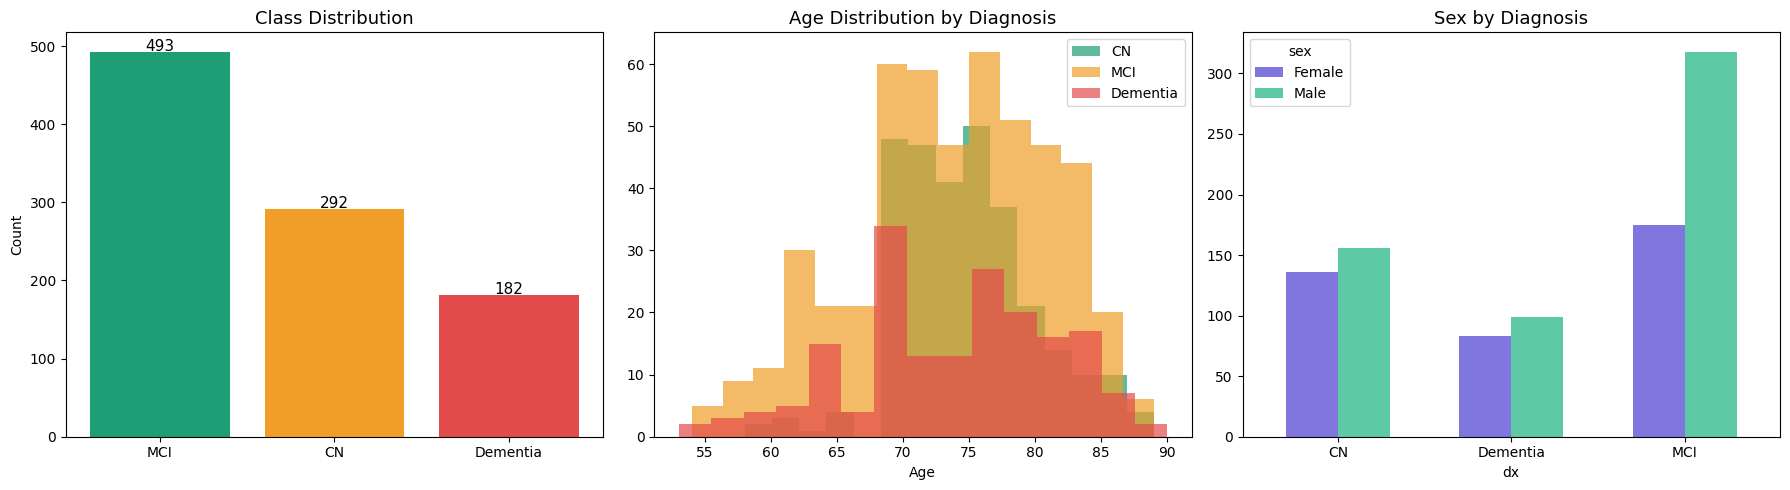

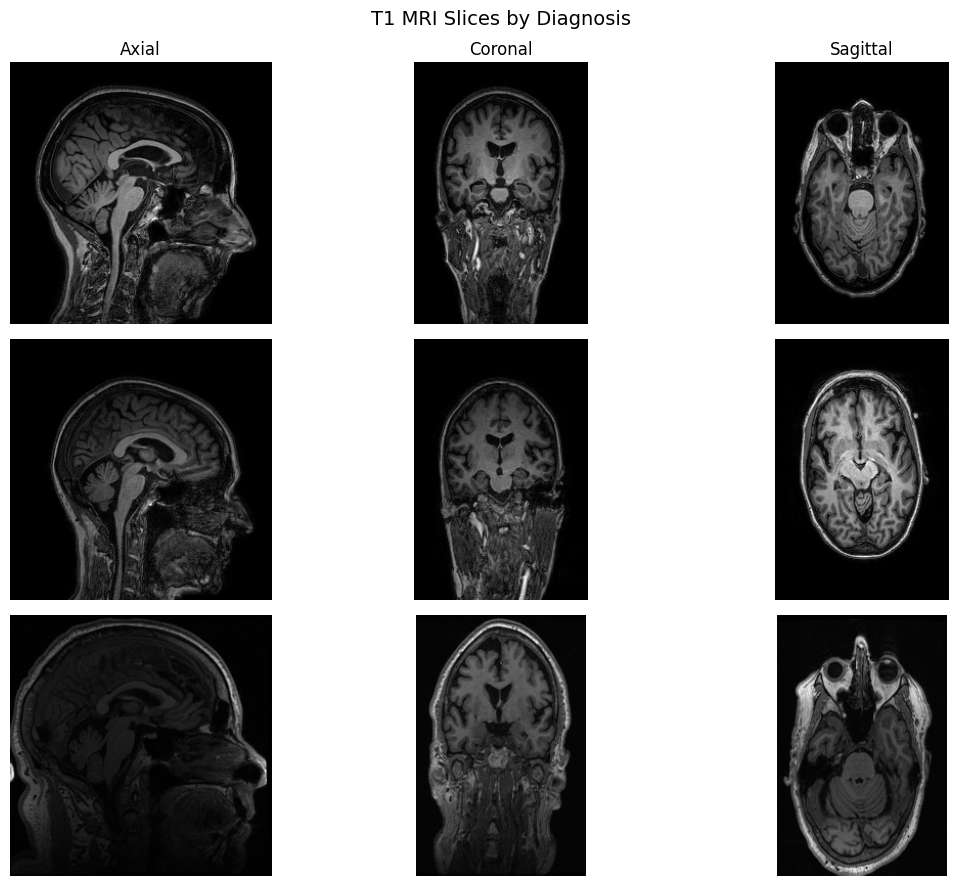

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dx_counts = manifest["dx"].value_counts()
axes[0].bar(dx_counts.index, dx_counts.values,
            color=["#1D9E75", "#EF9F27", "#E24B4A"], edgecolor="none")
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate(dx_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=11)

for dx, color in zip(["CN", "MCI", "Dementia"], ["#1D9E75", "#EF9F27", "#E24B4A"]):
    subset = manifest[manifest["dx"] == dx]["age"].dropna()
    axes[1].hist(subset, bins=15, alpha=0.7, label=dx,
                color=color, edgecolor="none")
axes[1].set_title("Age Distribution by Diagnosis", fontsize=13)
axes[1].set_xlabel("Age")
axes[1].legend()

sex_dx = manifest.groupby(["dx", "sex"]).size().unstack(fill_value=0)
sex_dx.plot(kind="bar", ax=axes[2],
            color=["#7F77DD", "#5DCAA5"], edgecolor="none", width=0.6)
axes[2].set_title("Sex by Diagnosis", fontsize=13)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("OUTPUTS/eda_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
label_names = {0: "CN", 1: "MCI", 2: "AD/Dementia"}

for label_idx, label_name in label_names.items():
    subset = manifest[manifest["label"] == label_idx]
    if subset.empty: continue
    vol  = nib.load(subset.iloc[0]["path"]).get_fdata()
    mid  = [s // 2 for s in vol.shape]
    slices = [vol[mid[0], :, :], vol[:, mid[1], :], vol[:, :, mid[2]]]

    for j, (sl, plane) in enumerate(zip(slices, ["Axial", "Coronal", "Sagittal"])):
        axes[label_idx][j].imshow(sl.T, cmap="gray", origin="lower")
        axes[label_idx][j].axis("off")
        if j == 0:
            axes[label_idx][j].set_ylabel(label_name, fontsize=12, fontweight="bold")
        if label_idx == 0:
            axes[label_idx][j].set_title(plane)

plt.suptitle("T1 MRI Slices by Diagnosis", fontsize=14)
plt.tight_layout()
plt.savefig("OUTPUTS/mri_slices.png", dpi=150, bbox_inches="tight")
plt.show()

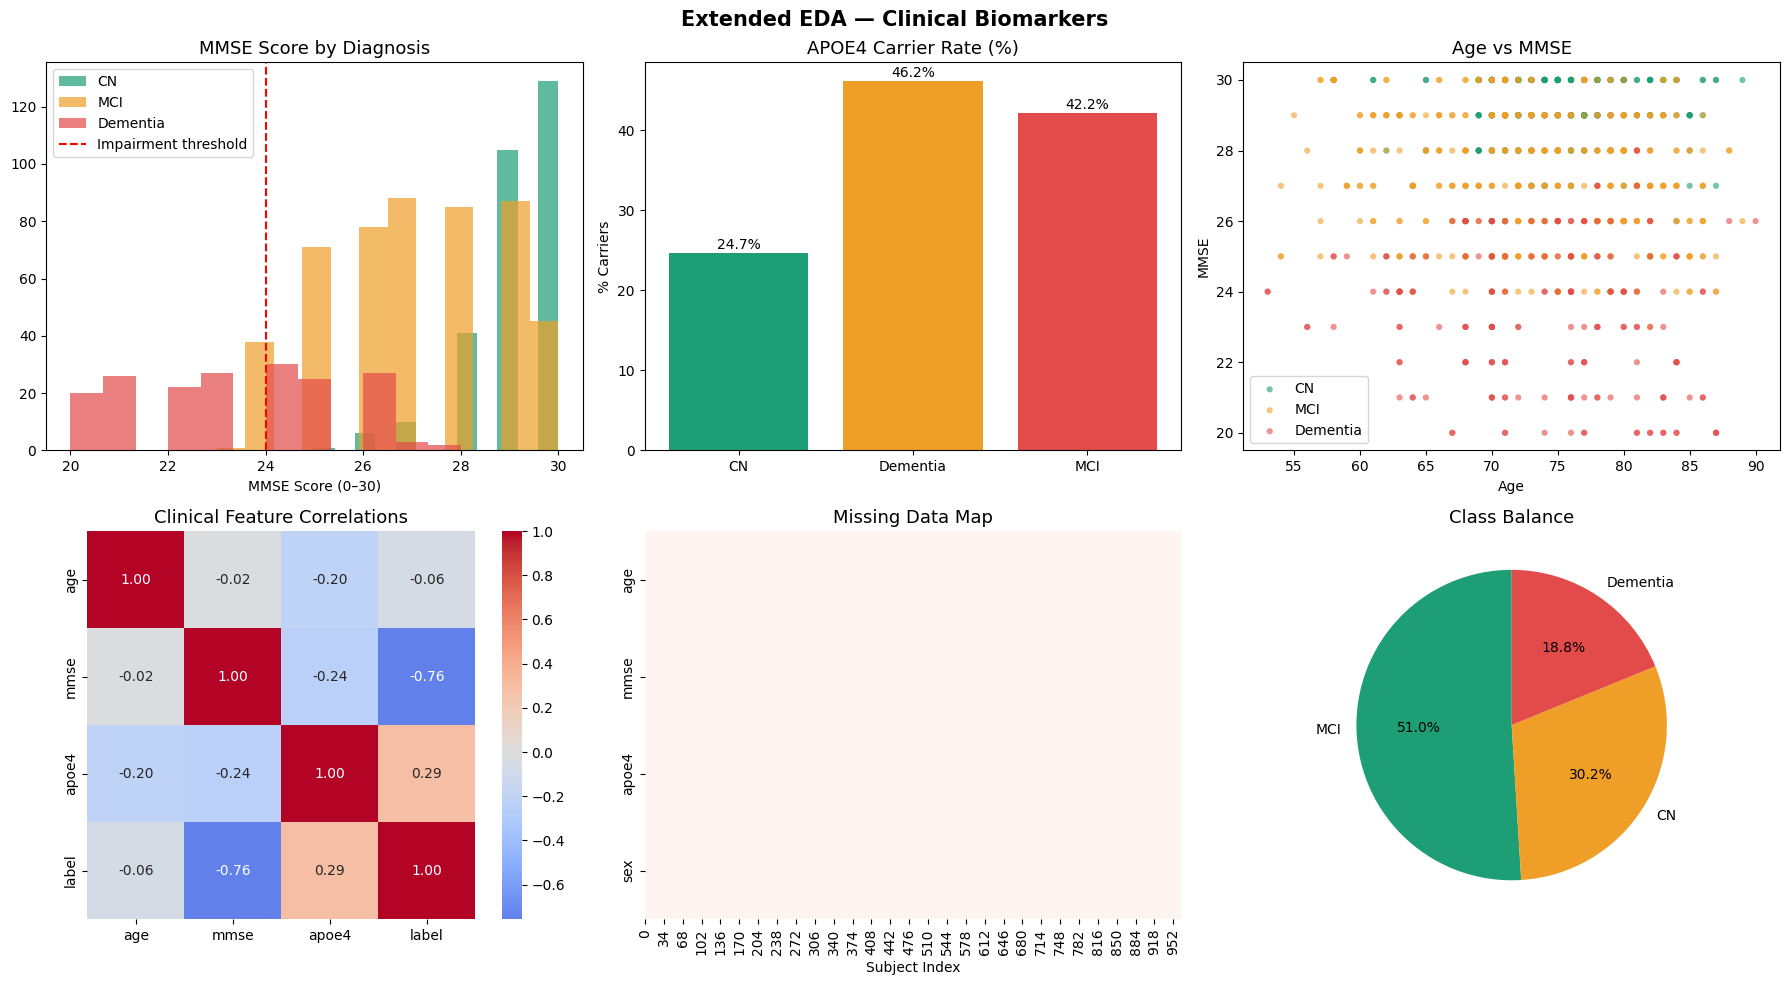


── Clinical Summary Statistics ──
            age         mmse       apoe4      
           mean   std   mean   std  mean   std
dx                                            
CN        74.75  5.06  29.16  0.97  0.29  0.51
Dementia  73.77  7.77  23.27  2.05  0.84  0.72
MCI       73.52  7.32  27.11  1.78  0.67  0.69


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for dx, color in zip(["CN", "MCI", "Dementia"], ["#1D9E75", "#EF9F27", "#E24B4A"]):
    subset = manifest[manifest["dx"] == dx]["mmse"].dropna()
    axes[0][0].hist(subset, bins=12, alpha=0.7, label=dx, color=color, edgecolor="none")
axes[0][0].set_title("MMSE Score by Diagnosis", fontsize=13)
axes[0][0].set_xlabel("MMSE Score (0–30)")
axes[0][0].axvline(24, color="red", linestyle="--", label="Impairment threshold")
axes[0][0].legend()

apoe_dx = manifest.groupby("dx")["apoe4"].apply(
    lambda x: (x == 1).sum() / x.notna().sum() * 100
).reset_index()
apoe_dx.columns = ["dx", "apoe4_pct"]
axes[0][1].bar(apoe_dx["dx"], apoe_dx["apoe4_pct"],
               color=["#1D9E75", "#EF9F27", "#E24B4A"], edgecolor="none")
axes[0][1].set_title("APOE4 Carrier Rate (%)", fontsize=13)
axes[0][1].set_ylabel("% Carriers")
for i, row in apoe_dx.iterrows():
    axes[0][1].text(i, row["apoe4_pct"] + 0.5, f"{row['apoe4_pct']:.1f}%", ha="center")

for label_idx, (dx, color) in enumerate(zip(["CN", "MCI", "Dementia"],
                                             ["#1D9E75", "#EF9F27", "#E24B4A"])):
    sub = manifest[manifest["dx"] == dx].dropna(subset=["age", "mmse"])
    axes[0][2].scatter(sub["age"], sub["mmse"], label=dx, alpha=0.6,
                       color=color, s=20, edgecolors="none")
axes[0][2].set_title("Age vs MMSE", fontsize=13)
axes[0][2].set_xlabel("Age"); axes[0][2].set_ylabel("MMSE")
axes[0][2].legend()

numeric_cols = ["age", "mmse", "apoe4", "label"]
corr = manifest[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1][0], square=True)
axes[1][0].set_title("Clinical Feature Correlations", fontsize=13)

missing = manifest[["age", "mmse", "apoe4", "sex"]].isnull().astype(int)
sns.heatmap(missing.T, cbar=False, cmap="Reds", ax=axes[1][1])
axes[1][1].set_title("Missing Data Map", fontsize=13)
axes[1][1].set_xlabel("Subject Index")

dx_counts = manifest["dx"].value_counts()
axes[1][2].pie(dx_counts.values, labels=dx_counts.index,
               colors=["#1D9E75", "#EF9F27", "#E24B4A"],
               autopct="%1.1f%%", startangle=90)
axes[1][2].set_title("Class Balance", fontsize=13)

plt.suptitle("Extended EDA — Clinical Biomarkers", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG.output_dir + "eda_extended.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Clinical Summary Statistics ──")
print(manifest.groupby("dx")[["age", "mmse", "apoe4"]].agg(["mean", "std"]).round(2))

In [11]:
import torchio as tio
import torch, os, shutil

PREP_DIR = "OUTPUTS/preprocessed/"
shutil.rmtree(PREP_DIR, ignore_errors=True)
os.makedirs(PREP_DIR, exist_ok=True)


preprocess_transforms = tio.Compose([
    tio.ToCanonical(),                             
    tio.RescaleIntensity(out_min_max=(0, 1)),       
    tio.Resample((1.0, 1.0, 1.0)),                 
    tio.CropOrPad((182, 218, 182)),              
    tio.Resample((2.0, 2.0, 2.0)),                
    tio.CropOrPad(CFG.target_shape),               
    tio.ZNormalization(                             
        masking_method=tio.ZNormalization.mean),
])

qc_log = []

def preprocess_volume(nifti_path, out_dir, subject_id):
    out_path = os.path.join(out_dir, f"{subject_id}.nii.gz")
    if os.path.exists(out_path):
        return out_path, "cached"
    try:
        img = nib.load(nifti_path)

        if np.prod(img.shape) < 1_000_000:
            return None, f"too_small:{img.shape}"

        if img.ndim == 4 and img.shape[3] > 1:
            return None, f"4D_timeseries:{img.shape}"

        subject      = tio.Subject(mri=tio.ScalarImage(nifti_path))
        preprocessed = preprocess_transforms(subject)
        preprocessed.mri.save(out_path)
        return out_path, "success"

    except Exception as e:
        return None, f"error:{str(e)[:80]}"

manifest["preprocessed_path"] = None
manifest["qc_status"] = None
total = len(manifest)

for idx, row in manifest.iterrows():
    out, status = preprocess_volume(row["path"], PREP_DIR, row["subject_id"])
    manifest.at[idx, "preprocessed_path"] = out
    manifest.at[idx, "qc_status"] = status
    done = idx + 1
    if done % 10 == 0 or done == total:
        log.info(f"Preprocessing: {done}/{total}")

qc_report = manifest["qc_status"].value_counts()
log.info(f"\nQC Report:\n{qc_report}")

manifest_clean = manifest[
    manifest["qc_status"].isin(["success", "cached"]) 
].copy()
manifest_clean.to_csv(CFG.output_dir + "manifest_preprocessed.csv", index=False)

print(f"\n✓ Usable: {len(manifest_clean)} subjects")
print(manifest["qc_status"].value_counts())

print(f"\n✓ Preprocessed: {len(manifest_clean)} subjects")
print(f"✗ Excluded: {len(manifest) - len(manifest_clean)} subjects")
print(f"\nQC breakdown:\n{qc_report}")
print(f"\nFinal class distribution:\n{manifest_clean['dx'].value_counts()}")

2026-05-05 08:42:16,326 | INFO | Preprocessing: 10/967
2026-05-05 08:42:22,229 | INFO | Preprocessing: 20/967
2026-05-05 08:42:30,218 | INFO | Preprocessing: 30/967
2026-05-05 08:42:38,422 | INFO | Preprocessing: 40/967
2026-05-05 08:42:47,610 | INFO | Preprocessing: 50/967
2026-05-05 08:42:53,531 | INFO | Preprocessing: 60/967
2026-05-05 08:43:01,217 | INFO | Preprocessing: 70/967
2026-05-05 08:43:07,400 | INFO | Preprocessing: 80/967
2026-05-05 08:43:14,760 | INFO | Preprocessing: 90/967
2026-05-05 08:43:21,314 | INFO | Preprocessing: 100/967
2026-05-05 08:43:28,335 | INFO | Preprocessing: 110/967
2026-05-05 08:43:35,629 | INFO | Preprocessing: 120/967
2026-05-05 08:43:42,630 | INFO | Preprocessing: 130/967
2026-05-05 08:43:48,821 | INFO | Preprocessing: 140/967
2026-05-05 08:43:55,328 | INFO | Preprocessing: 150/967
2026-05-05 08:44:02,566 | INFO | Preprocessing: 160/967
2026-05-05 08:44:10,136 | INFO | Preprocessing: 170/967
2026-05-05 08:44:17,640 | INFO | Preprocessing: 180/967
2


✓ Usable: 967 subjects
qc_status
success    675
cached     292
Name: count, dtype: int64

✓ Preprocessed: 967 subjects
✗ Excluded: 0 subjects

QC breakdown:
qc_status
success    675
cached     292
Name: count, dtype: int64

Final class distribution:
dx
MCI         493
CN          292
Dementia    182
Name: count, dtype: int64


In [12]:
train_augmentation = tio.Compose([
    tio.RandomFlip(axes=(0,), p=0.5),
    tio.RandomAffine(
        scales=(0.9, 1.1),
        degrees=10,
        translation=5,
        p=0.5
    ),
    tio.RandomElasticDeformation(
        num_control_points=7,
        max_displacement=7.5,
        p=0.3
    ),
    tio.RandomNoise(std=(0, 0.025), p=0.3),
    tio.RandomBiasField(coefficients=0.5, p=0.3),
    tio.RandomGamma(log_gamma=(-0.3, 0.3), p=0.2),
])

class ADNIDataset(Dataset):
    CLINICAL_MEAN = np.array([74.0, 0.5, 26.0, 0.3])
    CLINICAL_STD  = np.array([7.0,  0.5,  2.0, 0.46]) 

    def __init__(self, df, augment=False, return_clinical=True, tta_n=1):
        self.df              = df.reset_index(drop=True)
        self.augment         = augment
        self.return_clinical = return_clinical
        self.tta_n           = tta_n
          
    def __len__(self):
        return len(self.df)

    def _load_volume(self, path, augment):
        subject = tio.Subject(mri=tio.ScalarImage(path))
        if augment:
            subject = train_augmentation(subject)
        data = subject.mri.data.float()
        if data.shape[1:] != CFG.target_shape:
            data = F.interpolate(
                data.unsqueeze(0), size=CFG.target_shape,
                mode="trilinear", align_corners=False
            ).squeeze(0)
        data = (data - data.mean()) / (data.std() + 1e-8)
        data = data.clamp(-3, 3)/3.0
        return data                                       # ← return after normalizing

    def _get_clinical(self, row):
        """Normalized clinical features — NaN replaced with population mean."""
        def safe(val, idx):
            try:
                v = float(val)
                return v if not np.isnan(v) else self.CLINICAL_MEAN[idx]
            except (TypeError, ValueError):
                return self.CLINICAL_MEAN[idx]

        age   = safe(row.get("age"),   0)
        sex   = 1.0 if str(row.get("sex", "M")).upper() in ("M", "MALE", "1") else 0.0
        mmse  = safe(row.get("mmse"),  2)
        apoe4 = safe(row.get("apoe4"), 3)

        raw   = np.array([age, sex, mmse, apoe4], dtype=np.float32)
        normed = (raw - self.CLINICAL_MEAN) / (self.CLINICAL_STD + 1e-8)

        normed = np.nan_to_num(normed, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.tensor(normed, dtype=torch.float32)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        vols  = [self._load_volume(row["preprocessed_path"], self.augment)
                 for _ in range(self.tta_n)]
        data  = torch.stack(vols).mean(0) if self.tta_n > 1 else vols[0]

        if self.return_clinical:
            clinical = self._get_clinical(row)
            return data, clinical, torch.tensor(label, dtype=torch.long)
        return data, torch.tensor(label, dtype=torch.long)


def mixup_batch(x, y_onehot, alpha=0.2):
    """
    MixUp augmentation (Zhang et al., 2018, ICLR).
    Interpolates between pairs of samples for better decision boundaries.
    """
    if alpha <= 0:
        return x, y_onehot
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    idx = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[idx]
    mixed_y = lam * y_onehot + (1 - lam) * y_onehot[idx]
    return mixed_x, mixed_y

In [13]:
# Run this in a new cell to confirm which version is active:
import inspect
print(inspect.getsource(ADNIDataset._load_volume))

    def _load_volume(self, path, augment):
        subject = tio.Subject(mri=tio.ScalarImage(path))
        if augment:
            subject = train_augmentation(subject)
        data = subject.mri.data.float()
        if data.shape[1:] != CFG.target_shape:
            data = F.interpolate(
                data.unsqueeze(0), size=CFG.target_shape,
                mode="trilinear", align_corners=False
            ).squeeze(0)
        data = (data - data.mean()) / (data.std() + 1e-8)
        data = data.clamp(-3, 3)/3.0
        return data                                       # ← return after normalizing



In [14]:
print("manifest NaN check BEFORE clean:")
print(manifest[["age", "mmse", "apoe4"]].isna().sum())

manifest NaN check BEFORE clean:
age      0
mmse     0
apoe4    0
dtype: int64


In [15]:
print("manifest_clean source columns:", manifest_clean.columns.tolist())
print("manifest_clean NaN BEFORE filter:", manifest_clean[["age","mmse","apoe4"]].isna().sum())
manifest_clean = manifest[manifest["path"].notna()].copy()
manifest_clean = manifest_clean.reset_index(drop=True)
print(f"manifest_clean rebuilt: {len(manifest_clean)} subjects")
print(manifest_clean[["age","mmse","apoe4"]].isna().sum())

manifest_clean source columns: ['path', 'subject_id', 'label', 'dx', 'age', 'sex', 'apoe4', 'mmse', 'preprocessed_path', 'qc_status']
manifest_clean NaN BEFORE filter: age      0
mmse     0
apoe4    0
dtype: int64
manifest_clean rebuilt: 967 subjects
age      0
mmse     0
apoe4    0
dtype: int64


In [16]:
import os
manifest_clean = manifest[manifest["path"].notna()].copy()
manifest_clean = manifest_clean.reset_index(drop=True)

manifest_clean["preprocessed_path"] = manifest_clean["subject_id"].apply(
    lambda sid: os.path.join(PREP_DIR, f"{sid}.nii.gz")
)

manifest_clean["prep_exists"] = manifest_clean["preprocessed_path"].apply(os.path.exists)
print(f"Preprocessed files found: {manifest_clean['prep_exists'].sum()} / {len(manifest_clean)}")

manifest_clean = manifest_clean[manifest_clean["prep_exists"]].copy()
manifest_clean = manifest_clean.drop(columns=["prep_exists"]).reset_index(drop=True)

print(f"\nmanifest_clean: {len(manifest_clean)} subjects")
print(f"Class distribution:\n{manifest_clean['label'].value_counts()}")
print(f"NaN check:\n{manifest_clean[['age','mmse','apoe4']].isna().sum()}")

Preprocessed files found: 967 / 967

manifest_clean: 967 subjects
Class distribution:
label
1    493
0    292
2    182
Name: count, dtype: int64
NaN check:
age      0
mmse     0
apoe4    0
dtype: int64


In [17]:
print(manifest_clean[["age", "mmse", "apoe4"]].isna().sum())

age      0
mmse     0
apoe4    0
dtype: int64


In [18]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from torchvision.ops import StochasticDepth
torch.backends.cudnn.benchmark = False
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
import numpy as np
from typing import Tuple, Optional, Dict

class GlobalResponseNorm(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, 1, dim))
        self.beta  = nn.Parameter(torch.zeros(1, 1, 1, 1, dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        orig_dtype = x.dtype
        x32 = x.float()

        # 🔥 HARD clamp input first
        x32 = x32.clamp(-10.0, 10.0)

        # norm
        Gx = x32.norm(p=2, dim=(1, 2, 3), keepdim=True)

        # 🔥 clamp Gx itself (CRITICAL)
        Gx = Gx.clamp(max=1e3)

        # safe normalization
        denom = Gx.mean(dim=-1, keepdim=True).clamp(min=1e-3)
        Nx = Gx / denom

        # 🔥 tighter clamp (10 is too high)
        Nx = Nx.clamp(max=5.0)

        # output
        out = self.gamma.float() * (x32 * Nx) + self.beta.float() + x32

        # 🔥 final safety clamp
        out = out.clamp(-50.0, 50.0)

        return out.to(orig_dtype)


class MedNeXtBlock3D(nn.Module):
    def __init__(self, ch: int, expand: int = 4, ks: int = 7, drop: float = 0.0):
        super().__init__()
        mid = max(ch * expand, ch)
        self.dw   = nn.Conv3d(ch, ch, ks, padding=ks // 2, groups=ch, bias=False)
        self.ln   = nn.LayerNorm(ch, eps=1e-4)
        self.up   = nn.Linear(ch, mid)
        self.act  = nn.GELU()
        self.grn  = GlobalResponseNorm(mid)
        self.dn   = nn.Linear(mid, ch)
        self.drop = nn.Dropout(drop)
        self.stochastic_depth = StochasticDepth(p=0.1, mode="row")
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        r = x
        x = self.dw(x)

# 🔥 ADD THIS (most important fix)
        x = x.clamp(-10.0, 10.0)

        x = x.permute(0, 2, 3, 4, 1)

        # 🔥 move clamp BEFORE LN instead of after
        x = self.ln(x)

        # optional extra safety
        x = x.clamp(-10.0, 10.0)
        x = self.act(self.up(x))
        x = x.clamp(-10.0, 10.0) 
        x = self.grn(x)
        x = self.drop(self.dn(x))
        return self.stochastic_depth(x.permute(0,4,1,2,3)) + r


class MedNeXtDownsample(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 2):
        super().__init__()
        self.ln   = nn.LayerNorm(in_ch, eps=1e-4)
        self.conv = nn.Conv3d(in_ch, out_ch, stride, stride=stride, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 3, 4, 1)
        x = self.ln(x)
        return self.conv(x.permute(0, 4, 1, 2, 3))


# ──────────────────────────────────────────────────────────────────────────────
# 2. Persistence-Inspired Graph Builder  (vectorised nb6)
# ──────────────────────────────────────────────────────────────────────────────

class PersistenceInspiredGraphBuilder(nn.Module):
    def __init__(self, n_nodes: int = 12, persist_thresh: float = 0.1,
                 max_edge_scale: float = 2.0):
        super().__init__()
        self.n              = n_nodes
        self.thr            = persist_thresh
        self.max_edge_scale = max_edge_scale
        self.edge_mlp       = nn.Sequential(
            nn.Linear(2, 16), nn.GELU(), nn.Linear(16, 1), nn.Sigmoid()
        )

    _offsets = torch.tensor([[-1,0,0],[1,0,0],[0,-1,0],[0,1,0],[0,0,-1],[0,0,1]],
                             dtype=torch.long)

    @torch.no_grad()
    def _persistence_filtration(self, act: torch.Tensor):
        D, H, W = act.shape
        flat    = act.flatten()
        N_vox   = flat.numel()
        comp    = torch.full((N_vox,), -1, dtype=torch.long, device=flat.device)
        birth: Dict[int, float] = {}
        pairs   = []
        comp_cnt = 0
        idx_sorted = torch.argsort(flat, descending=True).tolist()

        offs = self._offsets.to(flat.device)          # (6, 3)

        def nb6(idx: int):
            d_ = idx // (H * W); hw = idx % (H * W)
            h_ = hw // W;        w_ = hw % W
            nd = d_ + offs[:, 0]; nh = h_ + offs[:, 1]; nw = w_ + offs[:, 2]
            valid = (nd >= 0) & (nd < D) & (nh >= 0) & (nh < H) & (nw >= 0) & (nw < W)
            return (nd[valid] * H * W + nh[valid] * W + nw[valid]).tolist()

        for idx in idx_sorted:
            val       = flat[idx].item()
            nbs_alive = [j for j in nb6(idx) if comp[j] >= 0]
            if not nbs_alive:
                comp[idx] = comp_cnt
                birth[comp_cnt] = val
                comp_cnt += 1
            else:
                cs     = list({comp[j].item() for j in nbs_alive})
                oldest = max(cs, key=lambda c: birth.get(c, -1e9))
                comp[idx] = oldest
                for c in cs:
                    if c != oldest and c in birth:
                        b = birth.pop(c)
                        if b - val >= self.thr:
                            pairs.append((c, b, val))

        for c, b in birth.items():
            pairs.append((c, b, 0.0))
        pairs.sort(key=lambda p: p[1] - p[2], reverse=True)
        selected = pairs[: self.n]

        coords  = torch.zeros(self.n, 3, device=flat.device)
        persist = torch.zeros(self.n,    device=flat.device)
        for i, (cid, b, d) in enumerate(selected):
            mask = (comp == cid).nonzero(as_tuple=False)
            if mask.numel():
                centroid = mask.float().mean(0).long()
                ic = centroid[0].clamp(0, N_vox - 1).item()
                d_ = ic // (H * W); hw = ic % (H * W); h_ = hw // W; w_ = hw % W
                coords[i] = torch.tensor([d_, h_, w_], dtype=torch.float)
            persist[i] = max(b - d, 0.0)
        return coords, persist

    def _build_adjacency(self, coords: torch.Tensor, persist: torch.Tensor,
                          device: torch.device) -> torch.Tensor:
        N     = self.n
        scale = persist.mean().clamp(min=1e-8)
        di    = coords.unsqueeze(1) - coords.unsqueeze(0)
        dists = di.norm(dim=-1)
        pi    = persist.unsqueeze(1).expand(N, N)
        pj    = persist.unsqueeze(0).expand(N, N)
        feat  = torch.stack([pi, pj], dim=-1).reshape(N * N, 2)
        gates = self.edge_mlp(feat).reshape(N, N)
        raw   = gates * (pi + pj) / (dists + 1.0)
        mask  = (dists <= self.max_edge_scale * scale).float()
        eye   = torch.eye(N, device=device)
        raw   = raw * mask * (1 - eye)
        raw   = (raw + raw.T) / 2.0
        raw = raw.clamp(min=0.0, max=10.0)
        return raw / (raw.max().detach() + 1e-6)

    def forward(self, feat_map: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, C, D, H, W = feat_map.shape
        act = feat_map.float().norm(p=2, dim=1)

# 🔥 ADD THIS (very important)
        act = act.clamp(0, 10.0)
        nf  = torch.zeros(B, self.n, C, device=feat_map.device, dtype=feat_map.dtype)
        adj = torch.zeros(B, self.n, self.n, device=feat_map.device, dtype=feat_map.dtype)
        for b in range(B):
            coords, persist = self._persistence_filtration(act[b])
            ci = coords[:, 0].long().clamp(0, D - 1)
            hi = coords[:, 1].long().clamp(0, H - 1)
            wi = coords[:, 2].long().clamp(0, W - 1)
            nf[b]  = feat_map[b, :, ci, hi, wi].T
            adj[b] = self._build_adjacency(coords, persist, feat_map.device)
        return nf, adj

class ApproxLLYCurvatureFlow(nn.Module):
    def __init__(self, n_nodes: int, flow_steps: int = 2):
        super().__init__()
        self.n             = n_nodes
        self.steps         = flow_steps
        self._log_tau      = nn.Parameter(torch.tensor(-1.0))
        self.aniso_weights = nn.Parameter(torch.ones(n_nodes))

    @property
    def tau(self):
        return F.softplus(self._log_tau)

    def _approx_lly_curvature(self, adj: torch.Tensor) -> torch.Tensor:
        deg  = adj.sum(-1).clamp(min=1e-8)
        mu_u = adj / deg.unsqueeze(-1)
        mu_v = adj / deg.unsqueeze(-2)
        W1   = (mu_u.unsqueeze(2) - mu_v.unsqueeze(1)).abs().sum(-1)
        kappa = 1.0 - W1 / (1.0 + 1e-8)
        aniso = torch.sigmoid(self.aniso_weights).unsqueeze(0).unsqueeze(-1)
        return kappa * aniso

    def forward(self, node_feats: torch.Tensor,
                adj: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        adj_e = adj
        for _ in range(self.steps):
            kappa = self._approx_lly_curvature(adj_e)
            kappa = kappa.clamp(-5, 5)
            adj_e = adj_e * torch.exp(-self.tau * kappa)
            adj_e = (adj_e + adj_e.transpose(1, 2)) / 2.0
            adj_e = adj_e.clamp(min=0.0)
            diag  = torch.eye(adj_e.size(-1), device=adj.device).bool()
            adj_e = adj_e.masked_fill(diag.unsqueeze(0), 0.0)
        return node_feats, adj_e

    def curvature_xai(self, adj: torch.Tensor) -> Dict[str, torch.Tensor]:
        kappa = self._approx_lly_curvature(adj)
        return {
            "curvature_matrix": kappa,
            "bottleneck_mask":  (kappa < 0).float(),
            "expander_mask":    (kappa > 0).float(),
            "mean_curvature":   kappa.mean(),
            "frac_bottleneck":  (kappa < 0).float().mean(),
        }



class SheafLayer(nn.Module):
 
    def __init__(self, node_dim: int, stalk_dim: int = 16,
                 n_nodes: int = 12, dropout: float = 0.1):
        super().__init__()
        self.S         = stalk_dim
        self.n_nodes   = n_nodes
        self.F_maps    = nn.Parameter(torch.randn(n_nodes, n_nodes, stalk_dim, node_dim) * 0.01)
        self.G_maps    = nn.Parameter(torch.randn(n_nodes, n_nodes, stalk_dim, node_dim) * 0.01)
        self.back_proj = nn.Linear(stalk_dim, node_dim, bias=False)
        self.sigma     = nn.Parameter(torch.tensor(0.5))
        self.norm      = nn.LayerNorm(node_dim)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        S = self.S
        fu_xu = torch.einsum('uvsd,bud->buvs', self.F_maps, x)   # (B,N,N,S)
        gv_xv = torch.einsum('uvsd,bvd->buvs', self.G_maps, x)   # (B,N,N,S)
        coboundary = fu_xu - gv_xv                                 # (B,N,N,S)
        w          = adj.unsqueeze(-1)                             # (B,N,N,1)
        weighted   = (coboundary * w).sum(dim=2)                   # (B,N,S)
        delta      = self.back_proj(weighted)                      # (B,N,D)
        sigma      = torch.sigmoid(self.sigma)
        return self.norm(self.drop(x - sigma * delta))


class SheafNeuralNetwork(nn.Module):
    def __init__(self, node_dim: int, stalk_dim: int = 16,
                 n_nodes: int = 12, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.layers    = nn.ModuleList([
            SheafLayer(node_dim, stalk_dim, n_nodes, dropout)
            for _ in range(n_layers)
        ])
        self.pool_attn = nn.Sequential(nn.Linear(node_dim, 1), nn.Tanh())

    def forward(self, node_feats: torch.Tensor,
                adj: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = node_feats
        for layer in self.layers:
            x = layer(x, adj)
        scores = F.softmax(self.pool_attn(x), dim=1)
        return (x * scores).sum(dim=1), x

    def sheaf_laplacian_spectrum(self, x: torch.Tensor,
                                  adj: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            deg = adj.sum(-1)
            L   = torch.diag_embed(deg) - adj
            return torch.linalg.eigvalsh(L)


class PoincareBall(nn.Module):
    def __init__(self, c: float = 1.0):
        super().__init__()
        self.c      = c
        self.sqrt_c = c ** 0.5

    def exp_map_zero(self, v: torch.Tensor) -> torch.Tensor:
        v = v.float()

        v_norm = v.norm(dim=-1, keepdim=True).clamp(min=1e-8, max=10.0)

        sqrt_c = self.sqrt_c
        scaled = (sqrt_c * v_norm).clamp(max=10.0)

        tanh_term = torch.tanh(scaled).clamp(max=1 - 1e-4)

        return tanh_term * v / (sqrt_c * v_norm + 1e-8)

    def log_map_zero(self, x: torch.Tensor) -> torch.Tensor:
        x=x.float()
        x_norm = x.norm(dim=-1, keepdim=True).clamp(min=1e-8)
        arg    = (self.sqrt_c * x_norm).clamp(max=1 - 1e-5)
        return torch.atanh(arg) / (self.sqrt_c * x_norm) * x

    def mobius_add(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        c  = self.c
        xy = (x * y).sum(dim=-1, keepdim=True)
        x2 = x.norm(dim=-1, keepdim=True) ** 2
        y2 = y.norm(dim=-1, keepdim=True) ** 2
        return ((1 + 2*c*xy + c*y2) * x + (1 - c*x2) * y) / (
            1 + 2*c*xy + c**2 * x2 * y2).clamp(min=1e-8)

    def dist_matrix(self, z: torch.Tensor) -> torch.Tensor:
        z=z.float()
        B, N, D = z.shape
        zi  = z.unsqueeze(2).expand(B, N, N, D).reshape(B*N*N, D)
        zj  = z.unsqueeze(1).expand(B, N, N, D).reshape(B*N*N, D)
        add  = self.mobius_add(-zi, zj)
        norm = add.norm(dim=-1).clamp(max=1 - 1e-2)
        return (2.0 / self.sqrt_c * torch.atanh(self.sqrt_c * norm)).reshape(B, N, N)

    def dist(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        add  = self.mobius_add(-x, y)
        norm = add.norm(dim=-1).clamp(max=1 - 1e-2)
        return 2.0 / self.sqrt_c * torch.atanh(self.sqrt_c * norm)

    # PoincareBall.project
    def project(self, x: torch.Tensor) -> torch.Tensor:
        norm  = x.norm(dim=-1, keepdim=True)
        scale = (1 - 1e-3)                              # ← was 1e-5, fp16-safe
        return x / norm.clamp(min=scale / (1 - 1e-8)) * scale

    # PoincareBall.busemann
    def busemann(self, x: torch.Tensor, xi: torch.Tensor) -> torch.Tensor:
        x  = x.float()   # ← add this
        xi = xi.float() 
        c      = self.c
        xi_n   = F.normalize(xi, dim=-1)
        x_norm = x.norm(dim=-1, keepdim=True).clamp(min=1e-8, max=1 - 1e-3)  # ← max clamp
        dot    = (x * xi_n).sum(dim=-1, keepdim=True)
        num    = (1 - 2 * c * dot + c * x_norm ** 2).clamp(min=1e-6)          # ← clamp num
        denom  = (1 - c * x_norm ** 2).clamp(min=1e-6)                        # ← clamp denom
        return torch.log(num / denom)

    def riemannian_grad(self, x: torch.Tensor, euc_grad: torch.Tensor) -> torch.Tensor:
        return ((1 - self.c * x.norm(dim=-1, keepdim=True)**2)**2 / 4.0) * euc_grad


class BusemannHierarchyEmbedding(nn.Module):
    """
    Reduced n_horoballs 4→2, hyp_dim 16→8 by default.
    Cuts fusion input from node_dim + 4*16 = node_dim+64
    to node_dim + 2*8 = node_dim+16.
    All topology and Riemannian mechanics unchanged.
    """
    def __init__(self, node_dim: int, hyp_dim: int = 8, curvature: float = 1.0,
                 n_horoballs: int = 2):
        super().__init__()
        self.hyp_dim         = hyp_dim
        self.n_horoballs     = n_horoballs
        self.log_c           = nn.Parameter(torch.zeros(1))
        self.horosphere_dirs = nn.Parameter(torch.randn(n_horoballs, hyp_dim))
        self.barcode_encoder = nn.Sequential(
            nn.Linear(5, 32), nn.LayerNorm(32), nn.GELU(),
            nn.Linear(32, 16), nn.LayerNorm(16), nn.GELU(),
            nn.Linear(16, hyp_dim),
        )
        self.fusion = nn.Sequential(
            nn.Linear(node_dim + hyp_dim * n_horoballs, node_dim),
            nn.LayerNorm(node_dim), nn.GELU()
        )
        self.barcode_encoder[-1].weight.register_hook(self._riemannian_hook)

    def _riemannian_hook(self, grad: torch.Tensor) -> torch.Tensor:
        c = torch.exp(self.log_c).clamp(0.01, 10.0).item()
        return grad * (1.0 / (1.0 + c))

    @property
    def curvature(self) -> float:
        return torch.exp(self.log_c).clamp(0.01, 10.0).item()

    def _barcode_features(self, adj: torch.Tensor) -> torch.Tensor:
        row_sum  = adj.sum(-1)
        row_max  = adj.max(-1).values
        row_min  = adj.min(-1).values.abs()
        lifetime = row_max - row_min
        midpoint = (row_max + row_sum / (adj.size(-1) + 1e-8)) / 2.0
        entropy  = -(adj.clamp(min=1e-8) * adj.clamp(min=1e-8).log()).sum(-1)
        phi      = torch.stack([row_sum, row_max, lifetime, midpoint, entropy], dim=-1)
        phi_max  = phi.abs().max(dim=-1, keepdim=True).values.clamp(min=1e-8)
        return phi / phi_max

    def forward(self, node_feats: torch.Tensor,
                adj: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # Force fp32 — atanh/tanh/log blow up in fp16 near the boundary
        orig_dtype  = node_feats.dtype
        node_feats  = node_feats.float()
        adj         = adj.float()

        c    = torch.exp(self.log_c).clamp(0.01, 10.0)
        ball = PoincareBall(c=c.item())
        phi  = self._barcode_features(adj)
        v    = self.barcode_encoder(phi.float())
        z    = ball.project(ball.exp_map_zero(v))

        B, N, HD = z.shape
        K        = self.n_horoballs
        xi_n     = F.normalize(self.horosphere_dirs.float(), dim=-1)
        xi_exp   = xi_n.unsqueeze(0).unsqueeze(1).expand(B, N, K, HD)
        z_exp    = z.unsqueeze(2).expand(B, N, K, HD)
        bus = ball.busemann(
            z_exp.reshape(B * N * K, HD),
            xi_exp.reshape(B * N * K, HD)
        ).reshape(B, N, K, 1).expand(B, N, K, HD).reshape(B, N, K * HD)

        out = self.fusion(torch.cat([node_feats, bus], dim=-1))
        return out.to(orig_dtype), z.to(orig_dtype)   # cast back for downstream


class EvidentialHead(nn.Module):
    def __init__(self, in_dim: int, n_classes: int,
                 hidden_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes), nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        alpha = self.net(x) + 1.0
        S     = alpha.sum(dim=-1, keepdim=True)
        return alpha / S, (alpha.size(-1) / S).squeeze(-1)

    def logits(self, x: torch.Tensor) -> torch.Tensor:
        alpha = self.net(x) + 1.0
        return (alpha / alpha.sum(dim=-1, keepdim=True)).log()



class UncertaintyGatedFusion(nn.Module):
    """
    Uncertainty-gated fusion preserved.
    Cross-modal interaction replaced with an efficient gated projection:
      h_fused = alpha * LayerNorm(mu_i + W_gate(mu_c) * mu_i)
              + (1-alpha) * LayerNorm(mu_c + W_gate2(mu_i) * mu_c)
    This retains cross-modal modulation at ~1/4 the parameter count
    compared to the dual-head cross-attention.
    """
    def __init__(self, graph_dim: int, clinical_dim: int = 4,
                 hidden_dim: int = 64, n_classes: int = 3, dropout: float = 0.3):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(graph_dim, hidden_dim),
                                        nn.LayerNorm(hidden_dim), nn.GELU())
        self.clin_proj = nn.Sequential(nn.Linear(clinical_dim, hidden_dim),
                                        nn.LayerNorm(hidden_dim), nn.GELU())
        self.img_head  = EvidentialHead(hidden_dim, n_classes, hidden_dim, dropout)
        self.clin_head = EvidentialHead(hidden_dim, n_classes, hidden_dim, dropout)
        # lightweight gated cross-modulation (no full attention)
        self.gate_i2c  = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())
        self.gate_c2i  = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())
        self.norm_i    = nn.LayerNorm(hidden_dim)
        self.norm_c    = nn.LayerNorm(hidden_dim)
        self.final_clf = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes)
        )

    def _fuse(self, mu_i: torch.Tensor, mu_c: torch.Tensor,
              unc_i: torch.Tensor, unc_c: torch.Tensor) -> torch.Tensor:
        alpha   = (unc_c / (unc_i + unc_c + 1e-6)).unsqueeze(-1)
        h_i2c   = self.norm_i(mu_i + self.gate_c2i(mu_c) * mu_i)
        h_c2i   = self.norm_c(mu_c + self.gate_i2c(mu_i) * mu_c)
        return alpha * h_i2c + (1 - alpha) * h_c2i

    def forward(self, h_G: torch.Tensor, node_feats: torch.Tensor,
                clinical: torch.Tensor) -> torch.Tensor:
        clinical = torch.nan_to_num(clinical, nan=0.0)
        mu_i     = self.img_proj(h_G)
        mu_c     = self.clin_proj(clinical)
        _, unc_i = self.img_head(mu_i)
        _, unc_c = self.clin_head(mu_c)
        return self.final_clf(self._fuse(mu_i, mu_c, unc_i, unc_c))

    def get_uncertainty(self, h_G: torch.Tensor, node_feats: torch.Tensor,
                        clinical: torch.Tensor) -> Dict[str, torch.Tensor]:
        clinical = torch.nan_to_num(clinical, nan=0.0)
        mu_i = self.img_proj(h_G)
        mu_c = self.clin_proj(clinical)
        _, unc_i = self.img_head(mu_i)
        _, unc_c = self.clin_head(mu_c)
        return {"img_uncertainty": unc_i, "clin_uncertainty": unc_c}


# ──────────────────────────────────────────────────────────────────────────────
# 9. Loss functions — unchanged
# ──────────────────────────────────────────────────────────────────────────────

class EvidentialFocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, weight=None, label_smoothing: float = 0.1):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
        self.ls     = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n = logits.size(1)
        with torch.no_grad():
            s = torch.zeros_like(logits).fill_(self.ls / (n - 1))
            s.scatter_(1, targets.unsqueeze(1), 1.0 - self.ls)
        lp   = F.log_softmax(logits, dim=1)
        loss = -(s * (1 - lp.exp()) ** self.gamma * lp).sum(dim=1)
        if self.weight is not None:
            loss = loss * self.weight[targets]
        return loss.mean()


class HyperbolicRegulariser(nn.Module):
    def __init__(self, lambda_hyp: float = 0.01, curvature: float = 1.0):
        super().__init__()
        self.lam  = lambda_hyp
        self.ball = PoincareBall(c=curvature)

    def forward(self, z: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        B, N, _ = z.shape
        dH   = self.ball.dist_matrix(z)
        triu = torch.triu(torch.ones(N, N, device=z.device), diagonal=1)
        w    = adj * triu.unsqueeze(0)
        return self.lam * (w * dH ** 2).sum() / (triu.sum() * B + 1e-8)


class AnisotropicRicciRegulariser(nn.Module):
    def __init__(self, lambda_ricci: float = 0.001, lambda_aniso: float = 0.0005):
        super().__init__()
        self.lam       = lambda_ricci
        self.lam_aniso = lambda_aniso

    def forward(self, kappa: torch.Tensor, adj: torch.Tensor,
                aniso_weights: torch.Tensor) -> torch.Tensor:
        mask       = (adj > 1e-6).float()
        mean_kappa = (kappa.abs() * mask).sum() / (mask.sum() + 1e-8)
        return self.lam * mean_kappa + self.lam_aniso * aniso_weights.var()


# ──────────────────────────────────────────────────────────────────────────────
# 10. Full model — AGCFNet-V4 Lite
# ──────────────────────────────────────────────────────────────────────────────

class AGCFNetV4(nn.Module):
    def __init__(self,
                 in_channels:   int   = 1,
                 n_classes:     int   = 3,
                 base_channels: int   = 24,
                 depths:        list  = None,
                 expand_ratio:  int   = 4,
                 node_dim:      int   = 64,
                 n_nodes:       int   = 12,
                 stalk_dim:     int   = 16,
                 hyp_dim:       int   = 8,
                 n_horoballs:   int   = 2,
                 curvature:     float = 1.0,
                 clinical_dim:  int   = 4,
                 dropout:       float = 0.2,
                 use_rfge:      bool  = True,
                 use_snn:       bool  = True,
                 use_hyphe:     bool  = True,
                 grad_ckpt:     bool  = False):   # ← True by default now
        super().__init__()
        if depths is None:
            depths = [2, 2, 2, 2]
        dims = [base_channels * (2 ** i) for i in range(4)]

        self.use_rfge   = use_rfge
        self.use_snn    = use_snn
        self.use_hyphe  = use_hyphe
        self.n_nodes    = n_nodes
        self.grad_ckpt  = grad_ckpt

        # ── encoder ──────────────────────────────────────────────────────────
        # Stride-2 stem: immediately halves spatial dims (96,112,96)→(48,56,48)
        # so stage1 GRN/Linear intermediates are 8× smaller in voxel count.
        self.stem   = nn.Conv3d(in_channels, dims[0], kernel_size=3,
                                stride=2, padding=1, bias=False)
        # Stage1 runs at half-res but is still the largest feature map.
        # Use expand_ratio=2 here (configurable via stem_expand) to keep
        # the GRN intermediate (B, D/2, H/2, W/2, ch*expand) manageable.
        expand_s1   = max(2, expand_ratio // 2)
        self.stage1 = self._make_stage(dims[0], dims[0], depths[0], expand_s1, dropout)
        self.down1  = MedNeXtDownsample(dims[0], dims[1])
        self.stage2 = self._make_stage(dims[1], dims[1], depths[1], expand_ratio, dropout)
        self.down2  = MedNeXtDownsample(dims[1], dims[2])
        self.stage3 = self._make_stage(dims[2], dims[2], depths[2], expand_ratio, dropout)
        self.down3  = MedNeXtDownsample(dims[2], dims[3])
        self.stage4 = self._make_stage(dims[3], dims[3], depths[3], expand_ratio, dropout)

        encoder_dim = dims[3]

        # ── graph ────────────────────────────────────────────────────────────
        self.graph_builder = PersistenceInspiredGraphBuilder(n_nodes)
        self.node_proj     = nn.Sequential(
            nn.Linear(encoder_dim, node_dim), nn.LayerNorm(node_dim), nn.GELU()
        )

        if use_hyphe:
            self.hyphe = BusemannHierarchyEmbedding(node_dim, hyp_dim, curvature, n_horoballs)
        if use_rfge:
            self.rfge  = ApproxLLYCurvatureFlow(n_nodes, flow_steps=2)
        if use_snn:
            self.snn   = SheafNeuralNetwork(node_dim, stalk_dim, n_nodes,
                                             n_layers=2, dropout=dropout)
        else:
            self.snn_fallback = nn.Sequential(
                nn.Linear(node_dim, node_dim), nn.LayerNorm(node_dim), nn.GELU()
            )

        self.fusion    = UncertaintyGatedFusion(node_dim, clinical_dim,
                                                node_dim, n_classes, dropout)
        self.hyp_reg   = HyperbolicRegulariser(0.01, curvature)
        self.ricci_reg = AnisotropicRicciRegulariser(0.001, 0.0005)
        self._init_weights()

    # ── helpers ───────────────────────────────────────────────────────────────

    def _make_stage(self, in_ch, out_ch, depth, expand, drop):
        blocks = []
        if in_ch != out_ch:
            blocks.append(nn.Conv3d(in_ch, out_ch, 1, bias=False))
        for _ in range(depth):
            blocks.append(MedNeXtBlock3D(out_ch, expand, drop=drop))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.trunc_normal_(m.weight, std=0.02)
                m.weight.data *= 0.5
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _encode(self, x: torch.Tensor) -> torch.Tensor:
        if self.grad_ckpt and self.training:
            x = self.stem(x)
            x = checkpoint(self.stage1, x, use_reentrant=False)
            x = self.down1(x)
            x = checkpoint(self.stage2, x, use_reentrant=False)
            x = self.down2(x)
            x = checkpoint(self.stage3, x, use_reentrant=False)
            x = self.down3(x)
            x = checkpoint(self.stage4, x, use_reentrant=False)
        else:
            x = self.stem(x)
            x = self.stage1(x); x = self.down1(x)
            x = self.stage2(x); x = self.down2(x)
            x = self.stage3(x); x = self.down3(x)
            x = self.stage4(x)
        return x

    def forward(self, x: torch.Tensor,
                clinical: Optional[torch.Tensor] = None,
                return_aux: bool = False):
        feat          = self._encode(x)
        feat = F.avg_pool3d(feat, kernel_size=4, stride=4)
        nf_raw, adj   = self.graph_builder(feat)
        node_feats    = self.node_proj(nf_raw)

        z_hyp = None
        if self.use_hyphe:
            with torch.autocast(device_type="cuda", enabled=False):
                node_feats, z_hyp = self.hyphe(node_feats.float(), adj.float())

        kappa       = None
        adj_evolved = adj
        if self.use_rfge:
            kappa                  = self.rfge._approx_lly_curvature(adj)
            node_feats, adj_evolved = self.rfge(node_feats, adj)

        if self.use_snn:
            h_G, node_feats_out = self.snn(node_feats, adj_evolved)
        else:
            node_feats_out = self.snn_fallback(node_feats)
            h_G            = node_feats_out.mean(dim=1)

        if clinical is None:
            clinical = torch.zeros(x.shape[0], 4, device=x.device)
        logits = self.fusion(h_G, node_feats_out, clinical)

        if return_aux:
            aux = {"z_hyp": z_hyp, "kappa": kappa, "adj_evolved": adj_evolved}
            if z_hyp is not None:
                aux["loss_hyp_reg"]   = self.hyp_reg(z_hyp, adj_evolved)
            if kappa is not None:
                aux["loss_ricci_reg"] = self.ricci_reg(kappa, adj,
                                                        self.rfge.aniso_weights)
                aux["xai"]            = self.rfge.curvature_xai(adj)
            aux["uncertainty"] = self.fusion.get_uncertainty(h_G, node_feats_out, clinical)
            return logits, aux
        return logits


    def get_ricci_curvatures(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        with torch.no_grad():
            feat = self._encode(x)
            _, adj = self.graph_builder(feat)
            return self.rfge.curvature_xai(adj) if self.use_rfge else {}

    def get_sheaf_laplacian_spectrum(self, x: torch.Tensor) -> torch.Tensor:
        feat = self._encode(x)
        with torch.no_grad():
            nf_raw, adj = self.graph_builder(feat)
            nf = self.node_proj(nf_raw)
            if self.use_hyphe:
                nf, _ = self.hyphe(nf, adj)
            adj_evo = adj
            if self.use_rfge:
                _, adj_evo = self.rfge(nf, adj)
            return self.snn.sheaf_laplacian_spectrum(nf, adj_evo) if self.use_snn \
                   else torch.zeros(1)

    def get_hyperbolic_hierarchy(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        with torch.no_grad():
            if not self.use_hyphe:
                return {}
            feat = self._encode(x)
            nf_raw, adj = self.graph_builder(feat)
            nf = self.node_proj(nf_raw)
            _, z = self.hyphe(nf, adj)
            ball = PoincareBall(c=self.hyphe.curvature)
            return {
                "hyp_coords":       z,
                "dist_matrix":      ball.dist_matrix(z),
                "norm_from_origin": z.norm(dim=-1),
                "curvature":        torch.tensor(self.hyphe.curvature),
            }

    def count_params(self) -> Tuple[int, int]:
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable



ABLATION_CONFIGS = {
    "full":          dict(use_rfge=True,  use_snn=True,  use_hyphe=True),
    "no_rfge":       dict(use_rfge=False, use_snn=True,  use_hyphe=True),
    "no_snn":        dict(use_rfge=True,  use_snn=False, use_hyphe=True),
    "no_hyphe":      dict(use_rfge=True,  use_snn=True,  use_hyphe=False),
    "no_rfge_snn":   dict(use_rfge=False, use_snn=False, use_hyphe=True),
    "no_rfge_hyphe": dict(use_rfge=False, use_snn=True,  use_hyphe=False),
    "baseline":      dict(use_rfge=False, use_snn=False, use_hyphe=False),
}


def build_model(config: str = "full", n_classes: int = 3,
                clinical_dim: int = 4, dropout: float = 0.2,
                grad_ckpt: bool = False) -> AGCFNetV4:   
    assert config in ABLATION_CONFIGS, f"Unknown config: {config}"
    return AGCFNetV4(
        in_channels   = 1,
        n_classes     = n_classes,
        base_channels = 32,          
        depths        = [2, 2, 4, 2],
        expand_ratio  = 4,
        node_dim      = 96,          
        n_nodes       = 12,
        stalk_dim     = 16,          
        hyp_dim       = 8,          
        n_horoballs   = 2,           
        curvature     = 1.0,
        clinical_dim  = clinical_dim,
        dropout       = dropout,
        grad_ckpt     = grad_ckpt,
        **ABLATION_CONFIGS[config],
    )


if __name__ == "__main__":
    from sklearn.utils.class_weight import compute_class_weight

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")

    print("── Parameter counts ──────────────────────────────────────")
    for cfg_name in ["full", "no_rfge", "no_snn", "no_hyphe", "baseline"]:
        m = build_model(config=cfg_name).to(device)
        t, tr = m.count_params()
        print(f"  [{cfg_name:15s}] total={t/1e6:.2f}M  trainable={tr/1e6:.2f}M")

    print("\n── Forward pass ──────────────────────────────────────────")
    model = build_model(config="full", grad_ckpt=False).to(device)
    vol   = torch.randn(2, 1, 96, 112, 96).to(device)
    vol = torch.clamp(vol, -3, 3) / 3.0
    clin  = torch.randn(2, 4).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(vol, clin)
    print(f"  Logits shape : {logits.shape}")

    with torch.no_grad():
        logits, aux = model(vol, clin, return_aux=True)
    print(f"  z_hyp        : {aux['z_hyp'].shape}")
    print(f"  kappa        : {aux['kappa'].shape}")
    print(f"  loss_hyp_reg : {aux['loss_hyp_reg'].item():.4f}")
    print(f"  loss_ricci   : {aux['loss_ricci_reg'].item():.4f}")
    print(f"  img_unc      : {aux['uncertainty']['img_uncertainty'].mean().item():.4f}")

    xai = model.get_ricci_curvatures(vol)
    print(f"\n  κ  mean={xai['curvature_matrix'].mean().item():.4f} "
          f"min={xai['curvature_matrix'].min().item():.4f} "
          f"max={xai['curvature_matrix'].max().item():.4f}")

    ev = model.get_sheaf_laplacian_spectrum(vol)
    print(f"  Fiedler λ₂  : {ev[:, 1].mean().item():.4f}")

    hyp = model.get_hyperbolic_hierarchy(vol)
    print(f"  Poincaré ‖z‖: {hyp['norm_from_origin'].mean().item():.4f}")

    labels = torch.tensor([0, 2]).to(device)
    cw = compute_class_weight("balanced", classes=np.array([0, 1, 2]),
                               y=np.array([0, 1, 2]))
    criterion = EvidentialFocalLoss(gamma=1.0,
                                    weight=torch.FloatTensor(cw).to(device))
    scaler = torch.amp.GradScaler(device="cuda")
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model.train()
    with torch.amp.autocast("cuda"):
        vol = torch.clamp(vol, -3, 3) / 3.0
        logits_tr, aux_tr = model(vol, clin, return_aux=True)
        loss = (criterion(logits_tr, labels)
                + aux_tr["loss_hyp_reg"]
                + aux_tr["loss_ricci_reg"])
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad()
    print("  Backward     : ✓")
    print("\n✓  AGCFNet-V4 Lite passed all checks.")

Device: cuda

── Parameter counts ──────────────────────────────────────
  [full           ] total=3.41M  trainable=3.41M
  [no_rfge        ] total=3.41M  trainable=3.41M
  [no_snn         ] total=2.53M  trainable=2.53M
  [no_hyphe       ] total=3.40M  trainable=3.40M
  [baseline       ] total=2.52M  trainable=2.52M

── Forward pass ──────────────────────────────────────────
  Logits shape : torch.Size([2, 3])
  z_hyp        : torch.Size([2, 12, 8])
  kappa        : torch.Size([2, 12, 12])
  loss_hyp_reg : 0.0009
  loss_ricci   : 0.0041
  img_unc      : 0.5814

  κ  mean=-0.4198 min=-2.8207 max=0.7311
  Fiedler λ₂  : -0.0000
  Poincaré ‖z‖: 0.1207
  Backward     : ✓

✓  AGCFNet-V4 Lite passed all checks.


In [19]:
print("manifest columns:", manifest.columns.tolist())
print("manifest shape:", manifest.shape)
print("path column sample:", manifest["path"].head(3).tolist())
print("path NaN count:", manifest["path"].isna().sum())

import os
manifest["file_exists"] = manifest["path"].apply(lambda p: os.path.exists(str(p)))
print(f"\nFiles that exist: {manifest['file_exists'].sum()} / {len(manifest)}")
print("Sample paths:")
print(manifest[["path", "file_exists"]].head(5))

manifest columns: ['path', 'subject_id', 'label', 'dx', 'age', 'sex', 'apoe4', 'mmse', 'preprocessed_path', 'qc_status']
manifest shape: (967, 10)
path column sample: ['OUTPUTS/nifti/002_S_0413/002_S_0413_301.nii.gz', 'OUTPUTS/nifti/002_S_0559/002_S_0559_2.nii.gz', 'OUTPUTS/nifti/002_S_0685/002_S_0685_2.nii.gz']
path NaN count: 0

Files that exist: 967 / 967
Sample paths:
                                             path  file_exists
0  OUTPUTS/nifti/002_S_0413/002_S_0413_301.nii.gz         True
1    OUTPUTS/nifti/002_S_0559/002_S_0559_2.nii.gz         True
2    OUTPUTS/nifti/002_S_0685/002_S_0685_2.nii.gz         True
3  OUTPUTS/nifti/002_S_0729/002_S_0729_601.nii.gz         True
4    OUTPUTS/nifti/002_S_0782/002_S_0782_2.nii.gz         True


In [20]:
from torch.utils.checkpoint import checkpoint_sequential

In [21]:
import gc
torch.cuda.empty_cache()
gc.collect()

422

In [22]:
print(torch.cuda.memory_summary())
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  96931 KiB |   2196 MiB |  24244 MiB |  24149 MiB |
|       from large pool |  73600 KiB |   2159 MiB |  23718 MiB |  23646 MiB |
|       from small pool |  23331 KiB |     65 MiB |    526 MiB |    503 MiB |
|---------------------------------------------------------------------------|
| Active memory         |  96931 KiB |   2196 MiB |  24244 MiB |  24149 MiB |
|       from large pool |  73600 KiB |   2159 MiB |  23718 MiB |

In [23]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"VRAM free       : {torch.cuda.memory_reserved(0) / 1e9:.2f} GB reserved")

print(f"\nDEVICE          : {DEVICE}")

param_device = next(model.parameters()).device
print(f"Model is on     : {param_device}")
assert param_device.type == "cuda", "❌ Model is on CPU — call model.to(DEVICE) first!"

dummy = torch.zeros(1).to(DEVICE)
print(f"Tensor device   : {dummy.device}")

print("\n✅ All checks passed — training will run on GPU")

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA H100 80GB HBM3 MIG 3g.40gb
VRAM total      : 42.28 GB
VRAM free       : 0.16 GB reserved

DEVICE          : cuda
Model is on     : cuda:0
Tensor device   : cuda:0

✅ All checks passed — training will run on GPU


In [24]:
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, cohen_kappa_score
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler
def make_weighted_sampler(df):                          # ← moved to top
    class_counts   = df["label"].value_counts().sort_index().values
    weights        = 1.0 / class_counts
    sample_weights = torch.tensor([weights[l] for l in df["label"].values],
                                   dtype=torch.float)
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            factor = (self.last_epoch + 1) / self.warmup_epochs
        else:
            progress = (self.last_epoch - self.warmup_epochs) / \
                       max(1, self.total_epochs - self.warmup_epochs)
            factor = 0.5 * (1 + np.cos(np.pi * progress))
        return [max(self.min_lr, base_lr * factor) for base_lr in self.base_lrs]


class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):  
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_score  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, score):
        if score is None or (isinstance(score, float) and np.isnan(score)):
            return self.should_stop   
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

def compute_metrics(labels, preds, probs):
    labels = np.array(labels)
    preds  = np.array(preds)
    probs  = np.array(probs)

    if probs.ndim == 1 or probs.shape[1] < CFG.n_classes:
        pad = np.zeros((len(probs), CFG.n_classes))
        pad[:, :probs.shape[1]] = probs
        probs = pad

    acc     = (preds == labels).mean()
    bal_acc = balanced_accuracy_score(labels, preds)
    f1_mac  = f1_score(labels, preds, average="macro", zero_division=0)
    f1_wei  = f1_score(labels, preds, average="weighted", zero_division=0)
    kappa   = cohen_kappa_score(labels, preds) if len(np.unique(preds)) > 1 else 0.0

    auc_scores = []
    for c in range(CFG.n_classes):
        if (labels == c).sum() >= 2: 
            try:
                binary_labels = (labels == c).astype(int)
                auc_c = roc_auc_score(binary_labels, probs[:, c])
                auc_scores.append(auc_c)
            except Exception:
                pass
    auc = float(np.mean(auc_scores)) if auc_scores else float("nan")

    return dict(acc=acc, bal_acc=bal_acc, f1_macro=f1_mac,
                f1_weighted=f1_wei, kappa=kappa, auc=auc)

def mixup_batch(x, y_onehot, alpha=0.2):
    if alpha <= 0:
        return x, y_onehot
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y_onehot + (1 - lam) * y_onehot[idx]


def train_one_epoch(model, loader, optimizer, scaler, current_epoch=0):
    model.train()
    total_loss, n = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        if len(batch) == 3:
            x, clin, y = batch
            clin = clin.to(DEVICE)
        else:
            x, y = batch
            clin = None

        x, y = x.to(DEVICE), y.to(DEVICE)
        
        if torch.isnan(x).any() or torch.isinf(x).any():
            log.warning("Skipping corrupted batch")
            continue

        y_onehot     = F.one_hot(y, CFG.n_classes).float()
       
        x_mix, y_mix = mixup_batch(x, y_onehot, CFG.mixup_alpha)
        x_mix = torch.clamp(x_mix, -3, 3) / 3.0

        optimizer.zero_grad(set_to_none=True)

        if DEVICE.type == "cuda":
            with torch.amp.autocast("cuda"):
                if clin is not None:
                    logits, aux = model(x_mix, clin, return_aux=True)
                else:
                    logits = model(x_mix)
                    aux    = {}

            logits = logits.float()
            y_mix  = y_mix.float()

            logits = logits - logits.max(dim=1, keepdim=True).values

            hard_labels = y_mix.argmax(1)  
            log_p = F.log_softmax(logits, dim=1)
            ce_soft = -(y_mix * log_p).sum(dim=1).mean()
            loss = 0.5 * criterion(logits, hard_labels) + 0.5 * ce_soft
            if "loss_hyp_reg" in aux:
                hyp_loss   = aux["loss_hyp_reg"].float()
                ricci_loss = aux["loss_ricci_reg"].float()
                if not (torch.isnan(hyp_loss) or torch.isinf(hyp_loss) or
                        torch.isnan(ricci_loss) or torch.isinf(ricci_loss)):
                    loss = loss + hyp_loss + ricci_loss

            if torch.isnan(loss) or torch.isinf(loss):
                log.warning("NaN loss — skipping batch")
                optimizer.zero_grad(set_to_none=True)
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            if clin is not None:
                logits, aux = model(x_mix, clin, return_aux=True)
            else:
                logits = model(x_mix)
                aux    = {}
            logits     = logits.float()
            log_p      = F.log_softmax(logits, dim=1)
            loss       = -(y_mix * log_p).sum(dim=1).mean()
            
            if "loss_hyp_reg" in aux:
                hyp_loss   = aux["loss_hyp_reg"]
                ricci_loss = aux["loss_ricci_reg"]
                if not (torch.isnan(hyp_loss) or torch.isnan(ricci_loss)):   
                    loss = loss + hyp_loss + ricci_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        if torch.isnan(loss):
            log.warning("NaN loss — skipping batch update")
            optimizer.zero_grad(set_to_none=True)
            continue

        with torch.no_grad():
            preds = logits.argmax(1).cpu().numpy()
            probs = F.softmax(logits, dim=1).cpu().numpy()

        total_loss += loss.item() * len(y)
        n          += len(y)
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs)

    if n == 0:
        return {"loss": float("nan"), "acc": 0.0, "auc": float("nan"),
                "f1_macro": 0.0, "f1_weighted": 0.0, "kappa": 0.0, "bal_acc": 0.0}

    metrics         = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = total_loss / n
    return metrics


@torch.no_grad()
def evaluate_tta(model, loader, criterion, n_tta=4):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []


    for batch in loader:
        x, clin, y = batch if len(batch) == 3 else (*batch, None)
        x, y = x.to(DEVICE), y.to(DEVICE)
        if clin is not None: clin = clin.to(DEVICE)
        flip_axes = [[], [2], [3], [4]]
        probs_list = []
        for axes in flip_axes:
            x_aug = torch.flip(x, dims=axes) if axes else x
            with torch.amp.autocast("cuda"):
                logits = model(x_aug, clin) if clin is not None else model(x_aug)
            probs_list.append(F.softmax(logits, dim=1))
        probs_avg = torch.stack(probs_list).mean(0)
        loss = F.nll_loss(
            torch.log(probs_avg.float().clamp(min=1e-8)), y,
            weight=torch.FloatTensor(cw).to(DEVICE)
        )

        preds = probs_avg.argmax(1).cpu().numpy()
        probs_np = probs_avg.cpu().numpy()
        total_loss += loss.item() * len(y)
        n += len(y)
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs_np)

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = total_loss / n
    return metrics, all_preds, all_labels, all_probs

CFG.lr              = 3e-5  
CFG.warmup_epochs   = 12         
CFG.epochs          = 150        
CFG.mixup_alpha     = 0.1      
CFG.label_smoothing = 0.05      
CFG.weight_decay    = 1e-4    
CFG.dropout         = 0.35      
scaler       = torch.amp.GradScaler(device="cuda") if DEVICE.type == "cuda" else None

fold_results = []
fold = 0

torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)

log.info(f"\n{'='*60}\nSingle Run (No K-Fold)\n{'='*60}")

train_df, val_df = train_test_split(
    manifest_clean, test_size=0.2,
    stratify=manifest_clean["label"],
    random_state=CFG.seed
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

train_loader = DataLoader(
    ADNIDataset(train_df, augment=True),
    batch_size   = CFG.batch_size,
    sampler      = make_weighted_sampler(train_df),
    num_workers  = 2,
    pin_memory   = (DEVICE.type == "cuda"),
    drop_last    = True)

val_loader = DataLoader(
    ADNIDataset(val_df, augment=False),
    batch_size   = CFG.batch_size,
    shuffle      = False,
    num_workers  = 2,
    pin_memory   = (DEVICE.type == "cuda"))
sample = next(iter(train_loader))
x = sample[0]
print(f"✅ Batch loaded — shape={x.shape}  min={x.min():.3f}  max={x.max():.3f}")
cw = compute_class_weight("balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values)
cw[1] = cw[1] * 1.5
cw = cw / cw.mean()  # renormalize
log.info(f"Adjusted class weights: {cw}")
criterion = EvidentialFocalLoss(
    gamma=1.0,
    weight=torch.FloatTensor(cw).to(DEVICE),
    label_smoothing=CFG.label_smoothing)

model = build_model(
    config="full", n_classes=CFG.n_classes,
    clinical_dim=4, dropout=CFG.dropout,
    grad_ckpt=False
).to(DEVICE)

encoder_params   = list(model.stem.parameters()) + \
                   list(model.stage1.parameters()) + \
                   list(model.stage2.parameters()) + \
                   list(model.stage3.parameters()) + \
                   list(model.stage4.parameters())
exotic_params    = list(model.hyphe.parameters()) + \
                       list(model.rfge.parameters())  + \
                       list(model.snn.parameters())
head_params      = list(model.fusion.parameters()) + \
                       list(model.node_proj.parameters())

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": 3e-5},
    {"params": exotic_params,  "lr": 1e-5},  
    {"params": head_params,    "lr": 3e-5},
], weight_decay=CFG.weight_decay)
scheduler = WarmupCosineScheduler(optimizer, CFG.warmup_epochs, CFG.epochs)
stopper   = EarlyStopping(patience=15, min_delta=0.001)

best_auc      = 0.0
best_val_loss = float("inf")
history = {k: [] for k in ["train_loss", "val_loss", "train_acc",
                                "val_acc", "train_auc", "val_auc", "lr"]}
preds, labels, probs = [], [], [] 
best_bal_acc  = 0.0
best_auc      = 0.0
best_val_loss = float("inf")

for epoch in range(CFG.epochs):
    tr                       = train_one_epoch(model, train_loader, optimizer, scaler, current_epoch=epoch)
    va, preds, labels, probs = evaluate_tta(model, val_loader, criterion)
    scheduler.step()

    _probs = np.array(probs)
    best_tuned_acc  = 0.0
    best_tuned_bal  = 0.0
    best_tuned_pred = None

    for t0 in [0.40, 0.45, 0.50]:
        for t2 in [0.40, 0.45, 0.50]:
            _preds = np.where(_probs[:, 0] > t0, 0,
                     np.where(_probs[:, 2] > t2, 2, 1))
            _acc = (_preds == np.array(labels)).mean()
            _bal = balanced_accuracy_score(labels, _preds)
            _score = 0.5 * _acc + 0.5 * _bal
            if _score > 0.5 * best_tuned_acc + 0.5 * best_tuned_bal:
                best_tuned_acc  = _acc
                best_tuned_bal  = _bal
                best_tuned_pred = _preds
                best_t          = (t0, t2)

    tuned_preds = best_tuned_pred
    tuned_acc   = best_tuned_acc
    tuned_bal   = best_tuned_bal

    history["train_loss"].append(tr["loss"])
    history["val_loss"].append(va["loss"])
    history["train_acc"].append(tr["acc"])
    history["val_acc"].append(va["acc"])
    history["train_auc"].append(tr.get("auc", float("nan")))
    history["val_auc"].append(va.get("auc", float("nan")))
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if np.isnan(tr["loss"]):
        log.error(f"NaN loss at epoch {epoch+1} — aborting fold")
        break

    auc_val   = va.get("auc", float("nan"))
    kappa_val = va.get("kappa", 0.0)

    if tuned_bal > best_bal_acc:
        best_bal_acc = tuned_bal
        best_auc     = auc_val
        torch.save(model.state_dict(), f"{CFG.output_dir}best_fold{fold}.pth")
        log.info(f"  ✓ Saved best model (bal_acc={best_bal_acc:.4f} auc={auc_val:.4f})")
    elif np.isnan(auc_val) and va["loss"] < best_val_loss:
        best_val_loss = va["loss"]
        torch.save(model.state_dict(), f"{CFG.output_dir}best_fold{fold}.pth")
        log.info(f"  ✓ Saved best model (val_loss={best_val_loss:.4f})")

    best_val_loss = min(best_val_loss, va["loss"])

    log.info(
        f"Ep {epoch+1:3d} | "
        f"Tr: loss={tr['loss']:.4f} acc={tr['acc']:.3f} auc={tr.get('auc', float('nan')):.3f} | "
        f"Va: loss={va['loss']:.4f} acc={va['acc']:.3f} auc={auc_val:.3f} "
        f"bal_acc={va['bal_acc']:.3f} | "
        f"Tuned: acc={tuned_acc:.3f} bal_acc={tuned_bal:.3f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if not np.isnan(auc_val):
        stop_score = auc_val
    else:
        stop_score = kappa_val if kappa_val > 0 else None

    if stopper.step(stop_score):
        log.info(f"Early stopping at epoch {epoch+1} (best={stopper.best_score:.4f})")
        break

fold_results.append({
    "fold":          fold,
    "best_auc":      best_auc,
    "best_val_loss": best_val_loss,
    "history":       history,
    "preds":         preds,
    "labels":        labels,
    "probs":         probs,
    "final_metrics": va,
})

log.info(f"Fold {fold+1} done | best_auc={best_auc:.4f} "
             f"best_val_loss={best_val_loss:.4f}")
torch.cuda.empty_cache()

valid_aucs = [r["best_auc"] for r in fold_results if not np.isnan(r["best_auc"])]
mean_auc   = np.mean(valid_aucs)
std_auc    = np.std(valid_aucs)
mean_acc   = np.mean([r["final_metrics"]["acc"] for r in fold_results])
mean_f1    = np.mean([r["final_metrics"]["f1_macro"] for r in fold_results])
mean_kappa = np.mean([r["final_metrics"]["kappa"] for r in fold_results])

log.info(
    f"\n{'='*60}\n"
    f"  AUC:   {mean_auc:.4f} ± {std_auc:.4f}\n"
    f"  Acc:   {mean_acc:.4f}\n"
    f"  F1:    {mean_f1:.4f}\n"
    f"  Kappa: {mean_kappa:.4f}\n"
    f"{'='*60}"
)


2026-05-05 08:50:03,065 | INFO | 
Single Run (No K-Fold)
2026-05-05 08:50:06,679 | INFO | Adjusted class weights: [0.86133974 0.76405644 1.37460382]


✅ Batch loaded — shape=torch.Size([8, 1, 96, 112, 96])  min=-1.000  max=1.000


2026-05-05 08:51:48,792 | INFO |   ✓ Saved best model (bal_acc=0.3333 auc=0.5633)
2026-05-05 08:51:48,793 | INFO | Ep   1 | Tr: loss=0.9324 acc=0.363 auc=0.533 | Va: loss=1.0848 acc=0.397 auc=0.563 bal_acc=0.377 | Tuned: acc=0.510 bal_acc=0.333 | lr=5.00e-06
2026-05-05 08:53:29,523 | INFO |   ✓ Saved best model (bal_acc=0.3897 auc=0.7092)
2026-05-05 08:53:29,527 | INFO | Ep   2 | Tr: loss=0.9022 acc=0.413 auc=0.601 | Va: loss=1.0767 acc=0.510 auc=0.709 bal_acc=0.623 | Tuned: acc=0.515 bal_acc=0.390 | lr=7.50e-06
2026-05-05 08:55:11,020 | INFO |   ✓ Saved best model (bal_acc=0.4091 auc=0.7667)
2026-05-05 08:55:11,022 | INFO | Ep   3 | Tr: loss=0.8942 acc=0.484 auc=0.660 | Va: loss=1.0354 acc=0.613 auc=0.767 bal_acc=0.657 | Tuned: acc=0.536 bal_acc=0.409 | lr=1.00e-05
2026-05-05 08:56:51,848 | INFO |   ✓ Saved best model (bal_acc=0.5067 auc=0.7977)
2026-05-05 08:56:51,850 | INFO | Ep   4 | Tr: loss=0.8896 acc=0.568 auc=0.738 | Va: loss=1.0184 acc=0.567 auc=0.798 bal_acc=0.673 | Tuned: ac

In [25]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score

model.load_state_dict(torch.load(f"{CFG.output_dir}best_fold0.pth"))

_, val_preds, val_labels, val_probs = evaluate_tta(model, val_loader, criterion)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

def tune_thresholds(probs, labels):
    best_thresh = [0.33, 0.33, 0.33]
    best_score  = 0.0
    for t0 in np.arange(0.15, 0.65, 0.05):
        for t2 in np.arange(0.15, 0.65, 0.05):
            t1 = 1.0 - t0 - t2
            if t1 <= 0.05:
                continue
            preds = np.where(probs[:, 0] > t0, 0,
                    np.where(probs[:, 2] > t2, 2, 1))
            score = balanced_accuracy_score(labels, preds)
            if score > best_score:
                best_score  = score
                best_thresh = [t0, t1, t2]
    return best_thresh, best_score

thresh, bal_acc = tune_thresholds(val_probs, val_labels)

tuned_preds = np.where(val_probs[:, 0] > thresh[0], 0,
              np.where(val_probs[:, 2] > thresh[2], 2, 1))

from sklearn.metrics import classification_report, cohen_kappa_score
print(f"Thresholds — CN: {thresh[0]:.2f}  MCI: {thresh[1]:.2f}  AD: {thresh[2]:.2f}")
print(f"Balanced acc (tuned): {bal_acc:.4f}")
print(f"Accuracy    (tuned): {(tuned_preds == val_labels).mean():.4f}")
print(f"Kappa       (tuned): {cohen_kappa_score(val_labels, tuned_preds):.4f}")
print(classification_report(val_labels, tuned_preds,
                             target_names=CFG.class_names))


Thresholds — CN: 0.45  MCI: 0.15  AD: 0.40
Balanced acc (tuned): 0.7972
Accuracy    (tuned): 0.7320
Kappa       (tuned): 0.5945
              precision    recall  f1-score   support

          CN       0.71      0.88      0.79        59
         MCI       0.86      0.57      0.68        99
          AD       0.61      0.94      0.74        36

    accuracy                           0.73       194
   macro avg       0.73      0.80      0.74       194
weighted avg       0.77      0.73      0.73       194



In [26]:
print(CFG.output_dir)
print(DEVICE)
print(len(manifest_clean))
model_test = build_model(config="full").to(DEVICE)
print("All ready — proceed with recovery")
del model_test

OUTPUTS/
cuda
967
All ready — proceed with recovery


In [27]:
import os
import glob

saved_models = sorted(glob.glob(f"{CFG.output_dir}best_fold*.pth"))
print(f"Saved model files: {saved_models}")
print(f"Fold results in memory: {len(fold_results)} folds")
for r in fold_results:
    print(f"  Fold {r['fold']+1}: best_auc={r['best_auc']:.4f}  best_val_loss={r['best_val_loss']:.4f}")

Saved model files: ['OUTPUTS/best_fold0.pth', 'OUTPUTS/best_fold1.pth', 'OUTPUTS/best_fold2.pth', 'OUTPUTS/best_fold3.pth', 'OUTPUTS/best_fold4.pth']
Fold results in memory: 1 folds
  Fold 1: best_auc=0.8903  best_val_loss=0.7568


RF (clinical only): 0.7444 ± 0.0408
SVM (clinical only): 0.7381 ± 0.0291
GBM (clinical only): 0.7338 ± 0.0398

Direct comparison (single run):
  AGCFNetV4 bal_acc:    0.7335
  Best baseline (mean): 0.7444
  Δ = -0.0108


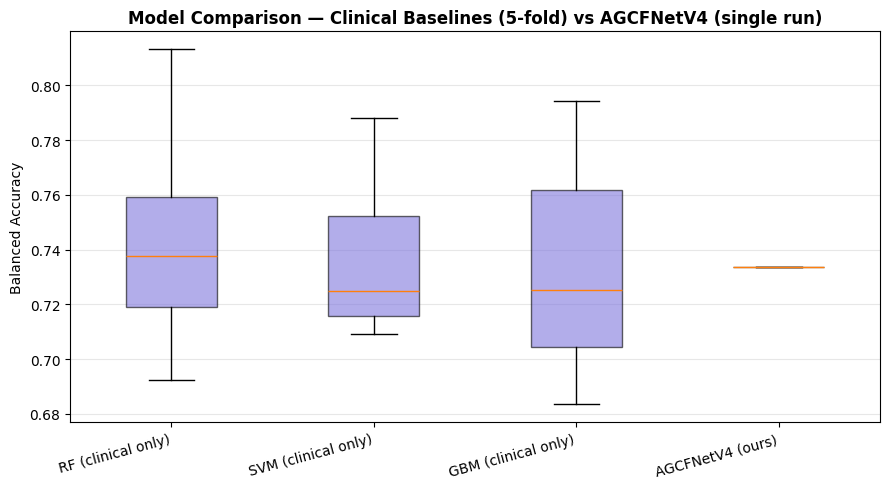

In [28]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import wilcoxon

FEATURE_COLS = ["age", "mmse", "apoe4"]
LABEL_COL    = "label"

df_baseline = manifest_clean[FEATURE_COLS + [LABEL_COL]].dropna().copy()
X_base = df_baseline[FEATURE_COLS].values
y_base = df_baseline[LABEL_COL].values

skf_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)

baselines = {
    "RF (clinical only)":   RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "SVM (clinical only)":  Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))]),
    "GBM (clinical only)":  GradientBoostingClassifier(n_estimators=200, random_state=42),
}

baseline_results = {}
for name, clf in baselines.items():
    scores = cross_val_score(clf, X_base, y_base, cv=skf_base,
                             scoring="balanced_accuracy", n_jobs=-1)
    baseline_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

your_bal_accs = [fold_results[0]["final_metrics"]["bal_acc"]]
best_baseline_scores = max(baseline_results.values(), key=lambda s: s.mean())
your_score = your_bal_accs[0]
best_baseline_mean = max(s.mean() for s in baseline_results.values())
print(f"\nDirect comparison (single run):")
print(f"  AGCFNetV4 bal_acc:    {your_score:.4f}")
print(f"  Best baseline (mean): {best_baseline_mean:.4f}")
print(f"  Δ = {your_score - best_baseline_mean:+.4f}")

baseline_results["AGCFNetV4 (ours)"] = np.array(your_bal_accs)

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(baseline_results))
ax.boxplot(baseline_results.values(), labels=baseline_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#7F77DD", alpha=0.6))
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Model Comparison — Clinical Baselines (5-fold) vs AGCFNetV4 (single run)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(CFG.output_dir + "baseline_comparison.png", dpi=150)
plt.show()

In [29]:
!pip install onnx onnxruntime

In [30]:
import os
import json
import numpy as np

best_fold_idx = max(range(len(fold_results)),
                    key=lambda i: fold_results[i]["best_auc"])
best_fold     = fold_results[best_fold_idx]

print(f"Best fold: {best_fold_idx + 1} | AUC={best_fold['best_auc']:.4f}")

model = build_model(
    config       = "full",
    n_classes    = CFG.n_classes,
    clinical_dim = 4,
    dropout      = CFG.dropout
).to(DEVICE)

model.load_state_dict(
    torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth",
               map_location=DEVICE)
)
model.eval()

print(f"  .pth  : {CFG.output_dir}best_fold{best_fold_idx}.pth ✓")

pt_path = f"{CFG.output_dir}best_model_full.pt"
torch.save(model, pt_path)
print(f"  .pt   : {pt_path} ✓")

onnx_path = f"{CFG.output_dir}best_model.onnx"
dummy_vol  = torch.randn(1, 1, 96, 112, 96).to(DEVICE)
dummy_clin = torch.zeros(1, 4).to(DEVICE)

with torch.no_grad():
    torch.onnx.export(
        model,
        (dummy_vol, dummy_clin),
        onnx_path,
        input_names  = ["volume", "clinical"],
        output_names = ["logits"],
        dynamic_axes = {
            "volume":   {0: "batch"},
            "clinical": {0: "batch"},
            "logits":   {0: "batch"},
        },
        opset_version = 17,
    )
print(f"  .onnx : {onnx_path} ✓")

metrics_path = f"{CFG.output_dir}cv_results.json"
save_data = {
    "mean_auc":   float(np.mean([r["best_auc"] for r in fold_results])),
    "std_auc":    float(np.std([r["best_auc"] for r in fold_results])),
    "mean_acc":   float(np.mean([r["final_metrics"]["acc"] for r in fold_results])),
    "mean_f1":    float(np.mean([r["final_metrics"]["f1_macro"] for r in fold_results])),
    "mean_kappa": float(np.mean([r["final_metrics"]["kappa"] for r in fold_results])),
    "best_fold":  best_fold_idx,
    "folds": [
        {
            "fold":          r["fold"],
            "best_auc":      float(r["best_auc"]),
            "best_val_loss": float(r["best_val_loss"]),
            "final_acc":     float(r["final_metrics"]["acc"]),
            "final_kappa":   float(r["final_metrics"]["kappa"]),
        }
        for r in fold_results
    ]
}
with open(metrics_path, "w") as f:
    json.dump(save_data, f, indent=2)
print(f"  .json : {metrics_path} ✓")

print("\nAll exports complete.")

Best fold: 1 | AUC=0.8903
  .pth  : OUTPUTS/best_fold0.pth ✓
  .pt   : OUTPUTS/best_model_full.pt ✓
  .onnx : OUTPUTS/best_model.onnx ✓
  .json : OUTPUTS/cv_results.json ✓

All exports complete.


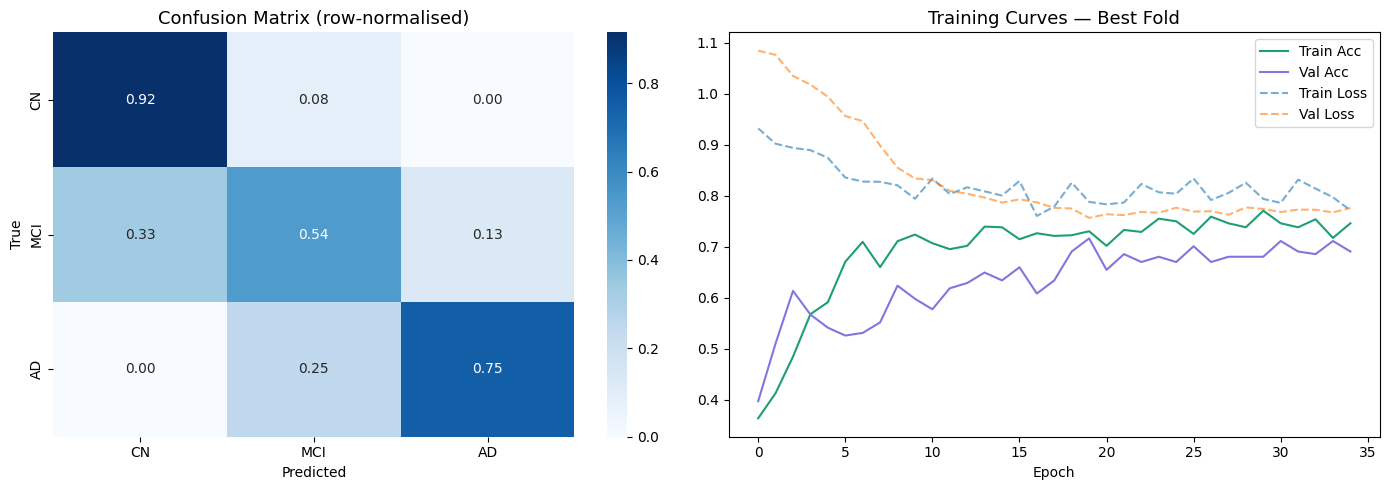


Classification Report:
              precision    recall  f1-score   support

          CN       0.62      0.92      0.74        59
         MCI       0.79      0.54      0.64        99
          AD       0.68      0.75      0.71        36

    accuracy                           0.69       194
   macro avg       0.70      0.73      0.70       194
weighted avg       0.72      0.69      0.68       194



In [31]:
best_fold  = max(fold_results, key=lambda r: r["final_metrics"]["kappa"])
all_preds  = best_fold["preds"]
all_labels = best_fold["labels"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Blues", ax=axes[0],
            xticklabels=["CN", "MCI", "AD"],
            yticklabels=["CN", "MCI", "AD"])
axes[0].set_title("Confusion Matrix (row-normalised)", fontsize=13)
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
h = best_fold.get("history", {})

if "train_acc" in h:
    axes[1].plot(h["train_acc"], label="Train Acc", color="#1D9E75")
if "val_acc" in h:
    axes[1].plot(h["val_acc"], label="Val Acc", color="#7F77DD")

if "train_loss" in h:
    axes[1].plot(h["train_loss"], label="Train Loss",
                 linestyle="--", alpha=0.6)

if "val_loss" in h:
    axes[1].plot(h["val_loss"], label="Val Loss",
                 linestyle="--", alpha=0.6)
h = best_fold["history"]
axes[1].set_title("Training Curves — Best Fold", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig("OUTPUTS/evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=["CN", "MCI", "AD"]))

In [36]:
def _get_graph_embedding(model, x, clin):
    feat          = model._encode(x)
    nf_raw, adj   = model.graph_builder(feat)
    node_feats    = model.node_proj(nf_raw)
    if model.use_hyphe:
        node_feats, _ = model.hyphe(node_feats, adj)
    if model.use_rfge:
        node_feats, adj = model.rfge(node_feats, adj)
    if model.use_snn:
        h_G, _ = model.snn(node_feats, adj)
    else:
        h_G = model.snn_fallback(node_feats).mean(dim=1)
    return h_G

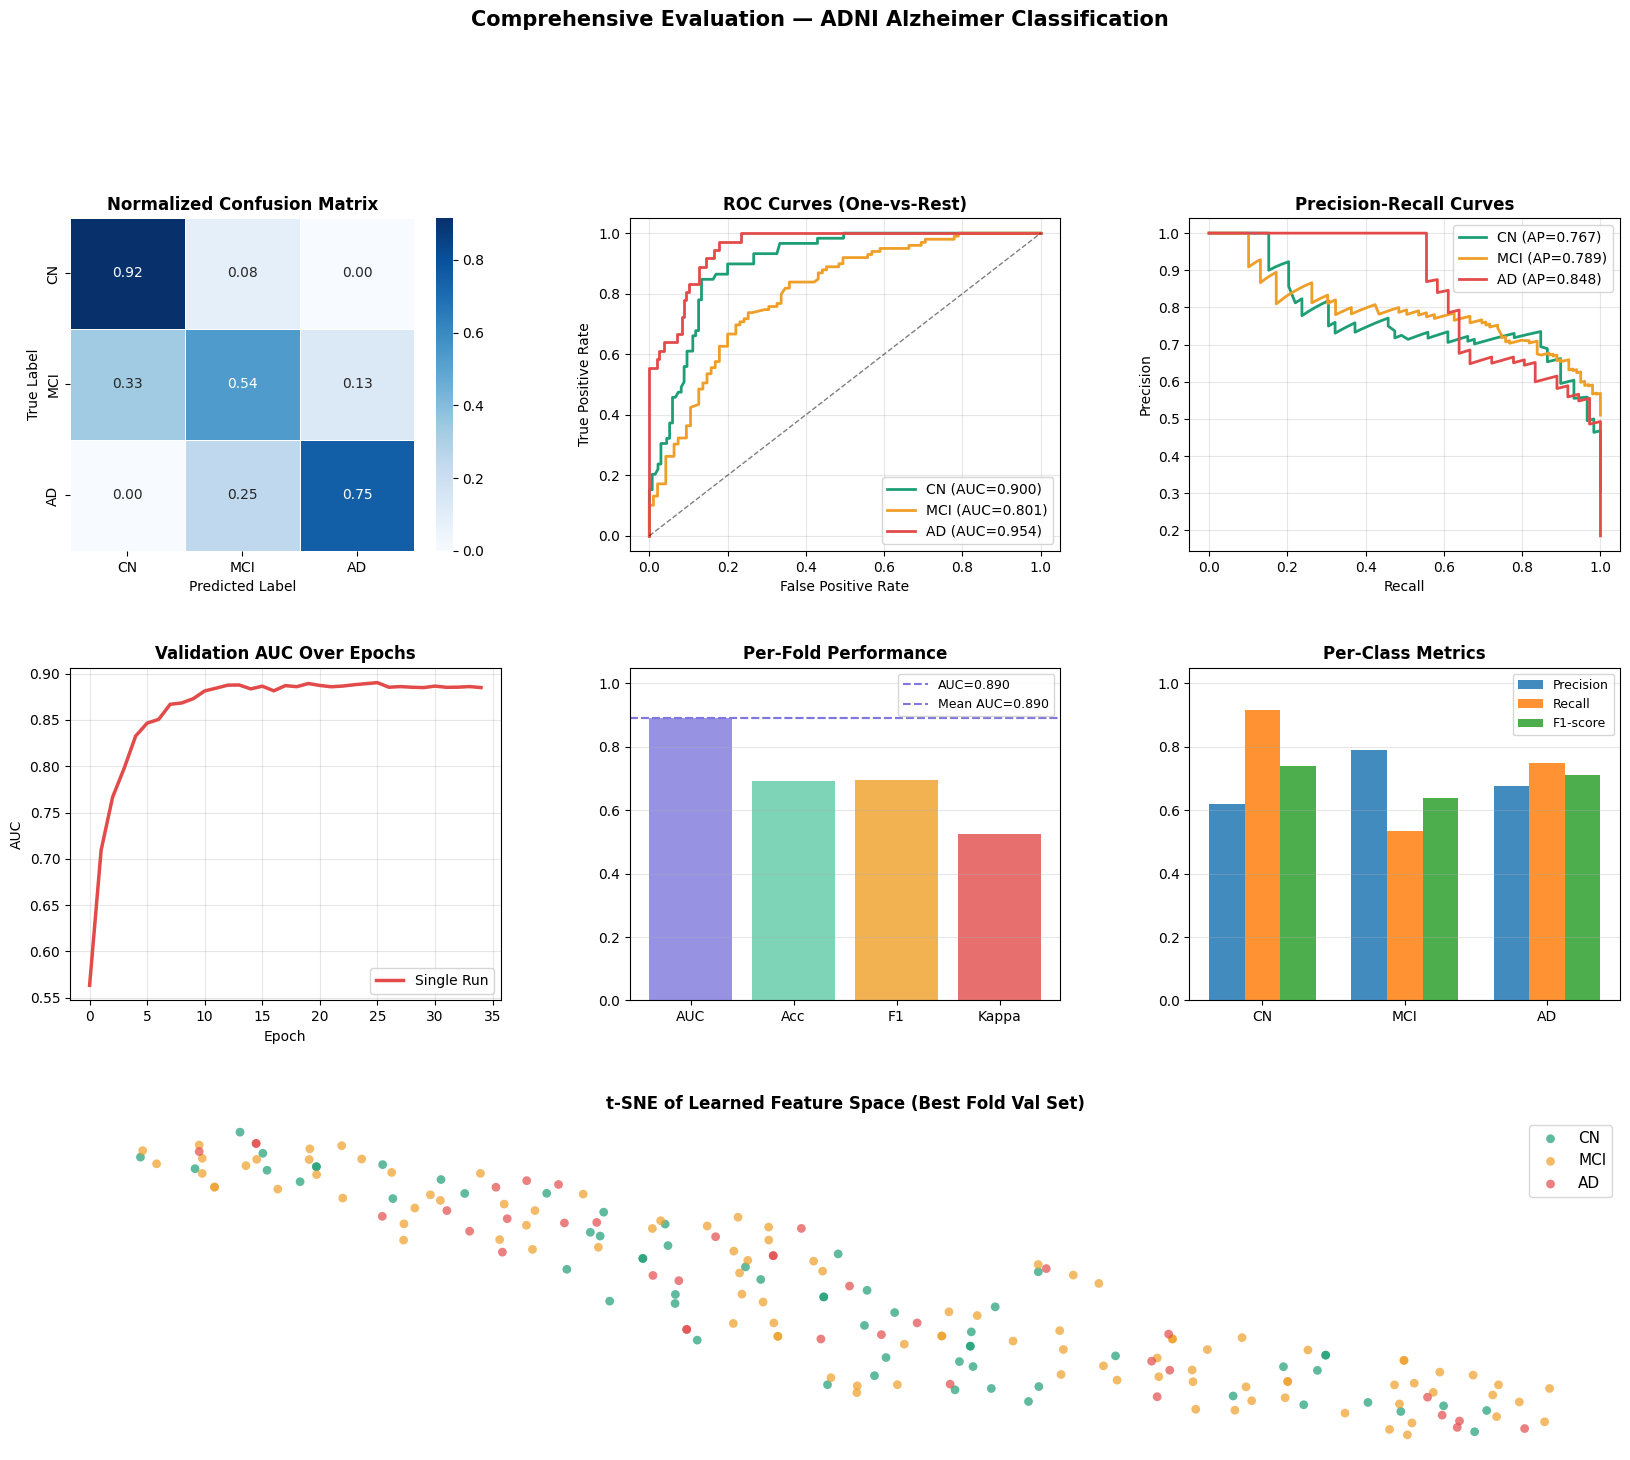


── Classification Report ──
              precision    recall  f1-score   support

          CN       0.62      0.92      0.74        59
         MCI       0.79      0.54      0.64        99
          AD       0.68      0.75      0.71        36

    accuracy                           0.69       194
   macro avg       0.70      0.73      0.70       194
weighted avg       0.72      0.69      0.68       194


Cohen's κ = 0.5235
Balanced Accuracy = 0.7335
Macro AUC = 0.8850


In [37]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

best_fold     = max(fold_results, key=lambda r: r["final_metrics"]["kappa"])
all_preds  = np.array(best_fold["preds"])
all_labels = np.array(best_fold["labels"])
all_probs  = np.array(best_fold["probs"])

fig = plt.figure(figsize=(20, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Blues", ax=ax1,
            xticklabels=CFG.class_names, yticklabels=CFG.class_names,
            linewidths=0.5)
ax1.set_title("Normalized Confusion Matrix", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Label"); ax1.set_xlabel("Predicted Label")

ax2 = fig.add_subplot(gs[0, 1])
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
colors_roc = ["#1D9E75", "#EF9F27", "#E24B4A"]
for i, (cls, color) in enumerate(zip(CFG.class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_score   = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC={auc_score:.3f})")
ax2.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
ax2.set_title("ROC Curves (One-vs-Rest)", fontsize=12, fontweight="bold")
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
for i, (cls, color) in enumerate(zip(CFG.class_names, colors_roc)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    pr_auc = auc(rec, prec)
    ax3.plot(rec, prec, color=color, lw=2, label=f"{cls} (AP={pr_auc:.3f})")
ax3.set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
ax3.legend(fontsize=10); ax3.grid(alpha=0.3)


ax4 = fig.add_subplot(gs[1, 0])
for r in fold_results:
    val_auc_hist = r["history"].get("val_auc", [])
    if val_auc_hist:
        ax4.plot(val_auc_hist, alpha=0.4, lw=1.5, color="#7F77DD")
best_hist    = best_fold["history"]
val_auc_hist = best_hist.get("val_auc", [])
if val_auc_hist:
    ax4.plot(val_auc_hist, lw=2.5, color="#E24B4A", label="Single Run")
ax4.set_title("Validation AUC Over Epochs", fontsize=12, fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("AUC")
ax4.legend(); ax4.grid(alpha=0.3)
ax4.set_xlabel("Epoch"); ax4.set_ylabel("AUC")
ax4.legend(); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])

r = fold_results[0]
metrics_bar = {"AUC": r["best_auc"], "Acc": r["final_metrics"]["acc"],
               "F1":  r["final_metrics"]["f1_macro"], "Kappa": r["final_metrics"]["kappa"]}
ax5.bar(metrics_bar.keys(), metrics_bar.values(), color=["#7F77DD","#5DCAA5","#EF9F27","#E24B4A"], alpha=0.8)
ax5.axhline(mean_auc, color="#7F77DD", linestyle="--", lw=1.5, label=f"AUC={mean_auc:.3f}")
ax5.set_title("Single Run Performance Summary", fontsize=12, fontweight="bold")
ax5.legend(fontsize=9); ax5.set_ylim(0, 1.05); ax5.grid(axis="y", alpha=0.3)
ax5.axhline(mean_auc, color="#7F77DD", linestyle="--", lw=1.5,
            label=f"Mean AUC={mean_auc:.3f}")
ax5.set_title("Per-Fold Performance", fontsize=12, fontweight="bold")
ax5.legend(fontsize=9); ax5.set_ylim(0, 1.05)

ax6 = fig.add_subplot(gs[1, 2])
from sklearn.metrics import classification_report
cr = classification_report(all_labels, all_preds,
                            target_names=CFG.class_names, output_dict=True)
metrics_per_class = {cls: cr[cls] for cls in CFG.class_names}
bar_data = {
    "Precision": [metrics_per_class[c]["precision"] for c in CFG.class_names],
    "Recall":    [metrics_per_class[c]["recall"]    for c in CFG.class_names],
    "F1-score":  [metrics_per_class[c]["f1-score"]  for c in CFG.class_names],
}
x = np.arange(len(CFG.class_names))
w = 0.25
for i, (metric, vals) in enumerate(bar_data.items()):
    ax6.bar(x + i*w, vals, w, label=metric, alpha=0.85)
ax6.set_xticks(x + w); ax6.set_xticklabels(CFG.class_names)
ax6.set_title("Per-Class Metrics", fontsize=12, fontweight="bold")
ax6.legend(fontsize=9); ax6.set_ylim(0, 1.05); ax6.grid(axis="y", alpha=0.3)

ax7 = fig.add_subplot(gs[2, :])
best_fold_idx = max(range(len(fold_results)), key=lambda i: fold_results[i]["final_metrics"]["kappa"])
model.load_state_dict(torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth"))
model.eval()

features_list, label_list = [], []

vis_loader = DataLoader(ADNIDataset(val_df, augment=False),
                        batch_size=CFG.batch_size, shuffle=False)
with torch.no_grad():
    for x, clin, y in vis_loader:
        x, clin = x.to(DEVICE), clin.to(DEVICE)
        feat = _get_graph_embedding(model, x, clin)
        features_list.append(feat.cpu().numpy())
        label_list.extend(y.numpy())

features_np = np.concatenate(features_list, axis=0)
labels_np   = np.array(label_list)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED)
emb  = tsne.fit_transform(features_np)

for i, (cls, color) in enumerate(zip(CFG.class_names, colors_roc)):
    mask = labels_np == i
    ax7.scatter(emb[mask, 0], emb[mask, 1], c=color, label=cls,
                s=40, alpha=0.7, edgecolors="none")
ax7.set_title("t-SNE of Learned Feature Space (Best Fold Val Set)",
              fontsize=12, fontweight="bold")
ax7.legend(fontsize=11); ax7.axis("off")

plt.suptitle("Comprehensive Evaluation — ADNI Alzheimer Classification",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig(CFG.output_dir + "evaluation_full.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=CFG.class_names))
print(f"\nCohen's κ = {cohen_kappa_score(all_labels, all_preds):.4f}")
print(f"Balanced Accuracy = {balanced_accuracy_score(all_labels, all_preds):.4f}")
all_probs_arr = np.array(all_probs)
all_probs_arr = all_probs_arr / all_probs_arr.sum(axis=1, keepdims=True)  
print(f"Macro AUC = {roc_auc_score(all_labels, all_probs_arr, multi_class='ovr', average='macro'):.4f}")

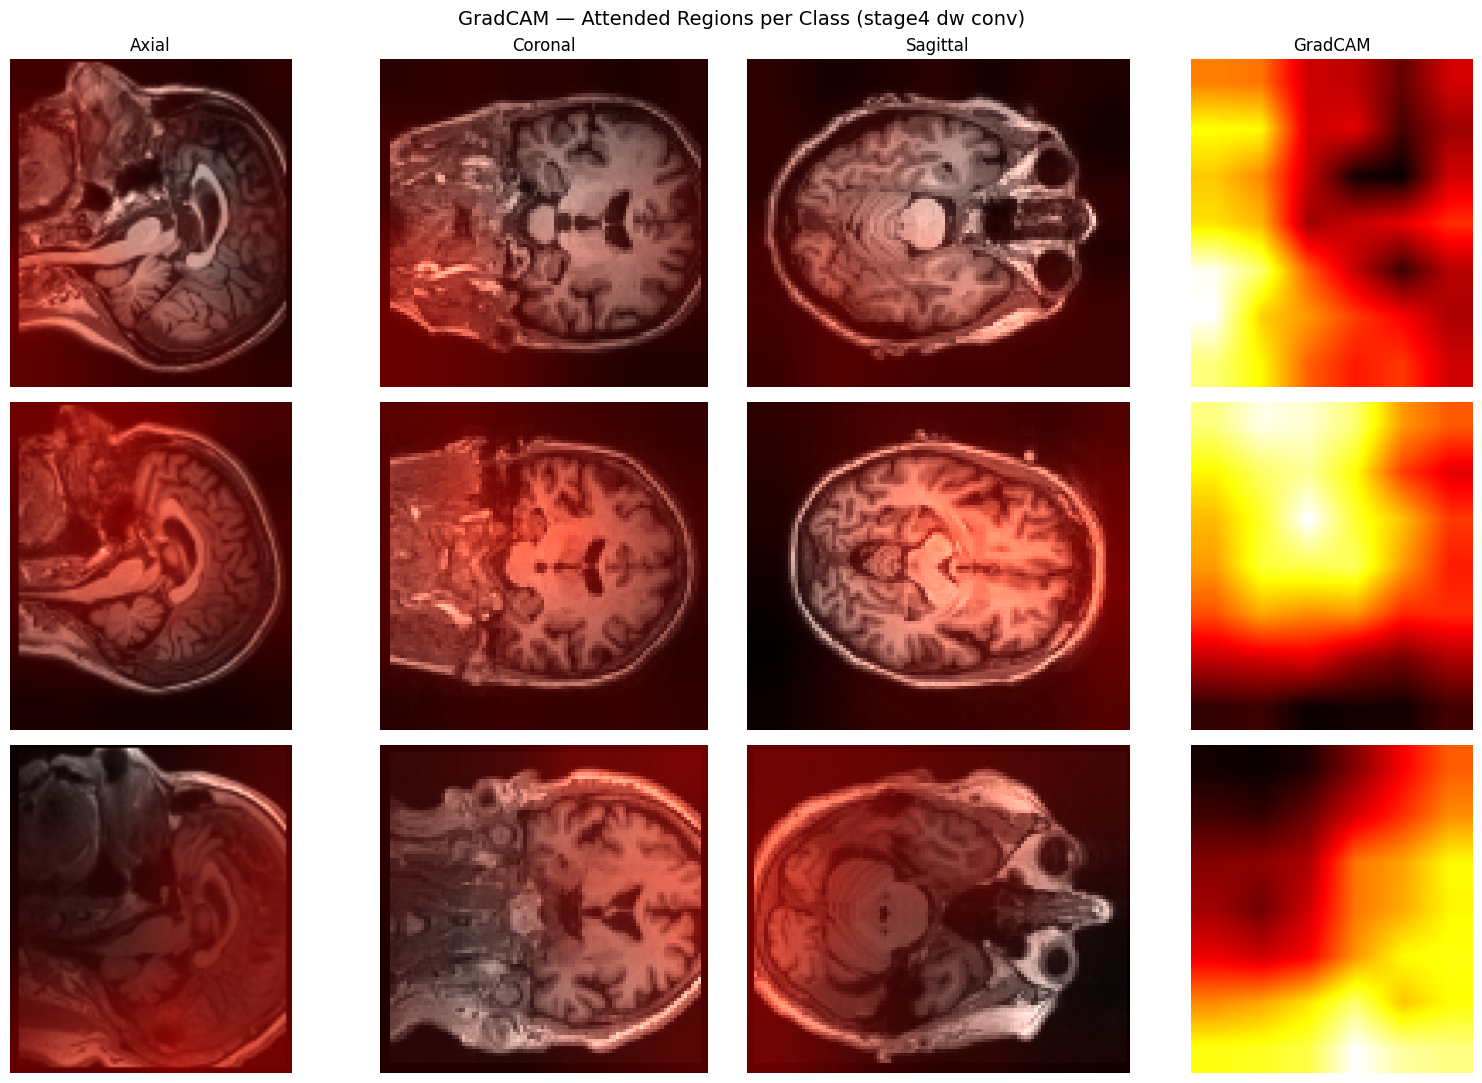

In [38]:
from captum.attr import LayerGradCam, LayerAttribution

best_fold_idx = max(range(len(fold_results)),
                    key=lambda i: fold_results[i]["best_auc"])
model.load_state_dict(
    torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth",
               map_location=DEVICE))
model = model.to(DEVICE).eval()

target_layer = model.stage4[-1].dw

grad_cam = LayerGradCam(
    lambda x: model(x, torch.zeros(x.shape[0], 4, device=DEVICE)),
    target_layer
)

label_names = {0: "CN", 1: "MCI", 2: "AD"}
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for label_idx in range(3):
    sample = manifest_clean[manifest_clean["label"] == label_idx].iloc[0]
    subj   = tio.Subject(mri=tio.ScalarImage(sample["preprocessed_path"]))
    vol    = F.interpolate(subj.mri.data.unsqueeze(0).float(),
                           size=CFG.target_shape, mode="trilinear",
                           align_corners=False)
    x_in   = vol.to(DEVICE).requires_grad_(True)

    attr = grad_cam.attribute(x_in, target=label_idx)
    cam  = LayerAttribution.interpolate(attr, CFG.target_shape, "trilinear")
    cam  = cam.squeeze().detach().cpu().numpy()
    cam  = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    vol_np = vol.squeeze().detach().cpu().numpy()
    mid    = [s // 2 for s in vol_np.shape]

    for j, plane_idx in enumerate(mid):
        if j == 0:   sl = vol_np[plane_idx, :, :]; h = cam[plane_idx, :, :]
        elif j == 1: sl = vol_np[:, plane_idx, :]; h = cam[:, plane_idx, :]
        else:        sl = vol_np[:, :, plane_idx]; h = cam[:, :, plane_idx]

        sl_n    = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
        overlay = np.stack([
            sl_n + h * 0.5,
            sl_n * (1 - h * 0.3),
            sl_n * (1 - h * 0.5),
        ], axis=-1).clip(0, 1)

        axes[label_idx][j].imshow(overlay, origin="lower")
        axes[label_idx][j].axis("off")
        if j == 0:
            axes[label_idx][j].set_ylabel(label_names[label_idx],
                                           fontsize=11, fontweight="bold")
        if label_idx == 0:
            axes[label_idx][j].set_title(["Axial", "Coronal", "Sagittal"][j])

    axes[label_idx][3].imshow(cam[mid[0], :, :], cmap="hot", origin="lower")
    axes[label_idx][3].axis("off")
    if label_idx == 0:
        axes[label_idx][3].set_title("GradCAM")

plt.suptitle("GradCAM — Attended Regions per Class (stage4 dw conv)", fontsize=14)
plt.tight_layout()
plt.savefig(CFG.output_dir + "gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

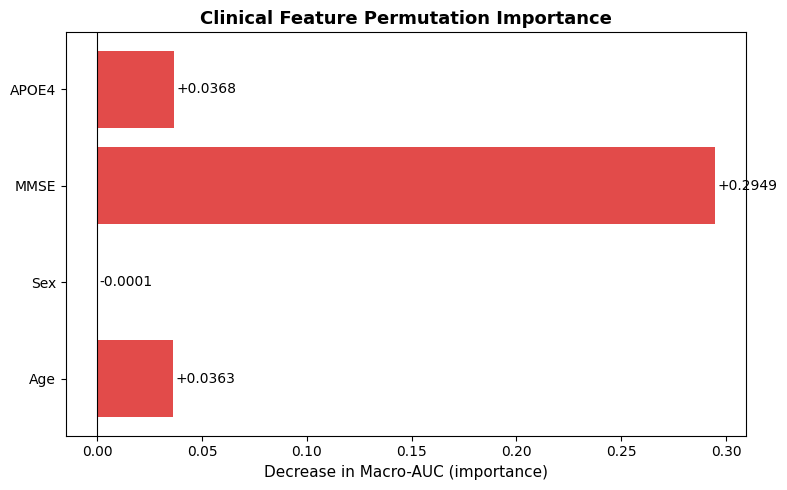


Baseline Macro-AUC: 0.8912
  MMSE      : ΔAUC = +0.2949
  APOE4     : ΔAUC = +0.0368
  Age       : ΔAUC = +0.0363
  Sex       : ΔAUC = -0.0001


In [42]:
model.load_state_dict(torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth"))
model.eval()

feature_names = ["Age", "Sex", "MMSE", "APOE4"]
n_repeats = 10
base_probs, base_labels = [], []

with torch.no_grad():
    for x, clin, y in val_loader:
        logits = model(x.to(DEVICE), clin.to(DEVICE))
        base_probs.extend(F.softmax(logits, dim=1).cpu().numpy())
        base_labels.extend(y.numpy())

base_auc = roc_auc_score(base_labels, base_probs,
                          multi_class="ovr", average="macro")

perm_importance = {}
for feat_idx, feat_name in enumerate(feature_names):
    aucs = []
    for _ in range(n_repeats):
        perm_probs = []
        with torch.no_grad():
            for x, clin, y in val_loader:
                clin_perm = clin.clone()
                clin_perm[:, feat_idx] = clin_perm[torch.randperm(len(clin_perm)), feat_idx]
                logits = model(x.to(DEVICE), clin_perm.to(DEVICE))
                perm_probs.extend(F.softmax(logits, dim=1).cpu().numpy())
        try:
            aucs.append(roc_auc_score(base_labels, perm_probs,
                                       multi_class="ovr", average="macro"))
        except Exception:
            aucs.append(base_auc)
    perm_importance[feat_name] = base_auc - np.mean(aucs)

fig, ax = plt.subplots(figsize=(8, 5))
names = list(perm_importance.keys())
vals  = list(perm_importance.values())
colors_bar = ["#E24B4A" if v > 0 else "#aaaaaa" for v in vals]
bars = ax.barh(names, vals, color=colors_bar, edgecolor="none")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Decrease in Macro-AUC (importance)", fontsize=11)
ax.set_title("Clinical Feature Permutation Importance", fontsize=13, fontweight="bold")
for bar, val in zip(bars, vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(CFG.output_dir + "clinical_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBaseline Macro-AUC: {base_auc:.4f}")
for k, v in sorted(perm_importance.items(), key=lambda x: -x[1]):
    print(f"  {k:10s}: ΔAUC = {v:+.4f}")

MCI converters (→AD):  284
Stable MCI:            483

AUC for MCI conversion prediction: 0.5870


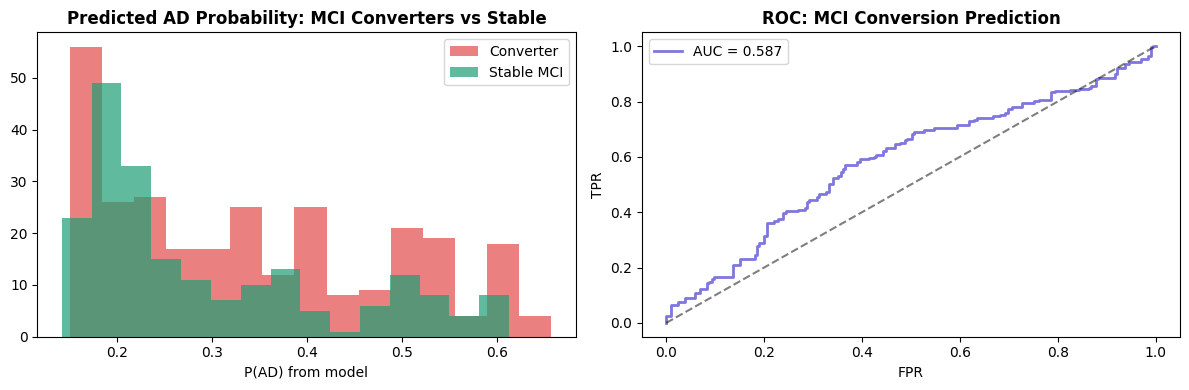


Clinical implication: The model predicts MCI-to-AD conversion
using only baseline T1 MRI + clinical data — enabling early intervention.


In [40]:
dxsum_long = load_rda("DXSUM.rda")

mci_rids = set(baseline[baseline["DX"] == "MCI"]["RID"].astype(int))
converters = set(
    dxsum_long[
        (dxsum_long["RID"].astype(int).isin(mci_rids)) &
        (dxsum_long["VISCODE"] != "bl") &
        (dxsum_long["DIAGNOSIS"].isin(["Dementia", "AD"]))
    ]["RID"].astype(int)
)
stable_mci = mci_rids - converters

print(f"MCI converters (→AD):  {len(converters)}")
print(f"Stable MCI:            {len(stable_mci)}")

mci_manifest = manifest_clean[manifest_clean["label"] == 1].copy()
mci_manifest["converter"] = mci_manifest["subject_id"].apply(
    lambda sid: int(sid.split("_S_")[1]) in converters
    if "_S_" in sid else False
)

mci_loader = DataLoader(
    ADNIDataset(mci_manifest, augment=False),
    batch_size=CFG.batch_size, shuffle=False, num_workers=2
)

model.load_state_dict(torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth"))
model.eval()

ad_probs, subjects = [], []
with torch.no_grad():
    for x, clin, y in mci_loader:
        logits = model(x.to(DEVICE), clin.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        ad_probs.extend(probs[:, 2])  # class 2 = AD

mci_manifest = mci_manifest.iloc[:len(ad_probs)].copy()
mci_manifest["predicted_ad_prob"] = ad_probs

if mci_manifest["converter"].sum() > 0 and (~mci_manifest["converter"]).sum() > 0:
    from sklearn.metrics import roc_auc_score, roc_curve
    
    auc_conv = roc_auc_score(mci_manifest["converter"].astype(int),
                              mci_manifest["predicted_ad_prob"])
    print(f"\nAUC for MCI conversion prediction: {auc_conv:.4f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    for group, color, label in [(True, "#E24B4A", "Converter"), (False, "#1D9E75", "Stable MCI")]:
        subset = mci_manifest[mci_manifest["converter"] == group]["predicted_ad_prob"]
        axes[0].hist(subset, bins=15, alpha=0.7, color=color, label=label, edgecolor="none")
    axes[0].set_title("Predicted AD Probability: MCI Converters vs Stable", fontweight="bold")
    axes[0].set_xlabel("P(AD) from model"); axes[0].legend()
    
    fpr, tpr, _ = roc_curve(mci_manifest["converter"].astype(int),
                              mci_manifest["predicted_ad_prob"])
    axes[1].plot(fpr, tpr, color="#7F77DD", lw=2, label=f"AUC = {auc_conv:.3f}")
    axes[1].plot([0,1],[0,1], "k--", alpha=0.5)
    axes[1].set_title("ROC: MCI Conversion Prediction", fontweight="bold")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(CFG.output_dir + "mci_conversion.png", dpi=150)
    plt.show()
    
    print("\nClinical implication: The model predicts MCI-to-AD conversion")
    print("using only baseline T1 MRI + clinical data — enabling early intervention.")
else:
    print("Not enough converter/stable samples in manifest_clean for this analysis.")
    print("(This works best with the full ADNI longitudinal dataset.)")

Subjects with ≥3 visits AND MRI: 640
Subjects with full trajectories: 40

MCI→AD conversion prediction AUC (from baseline MRI): 0.8000


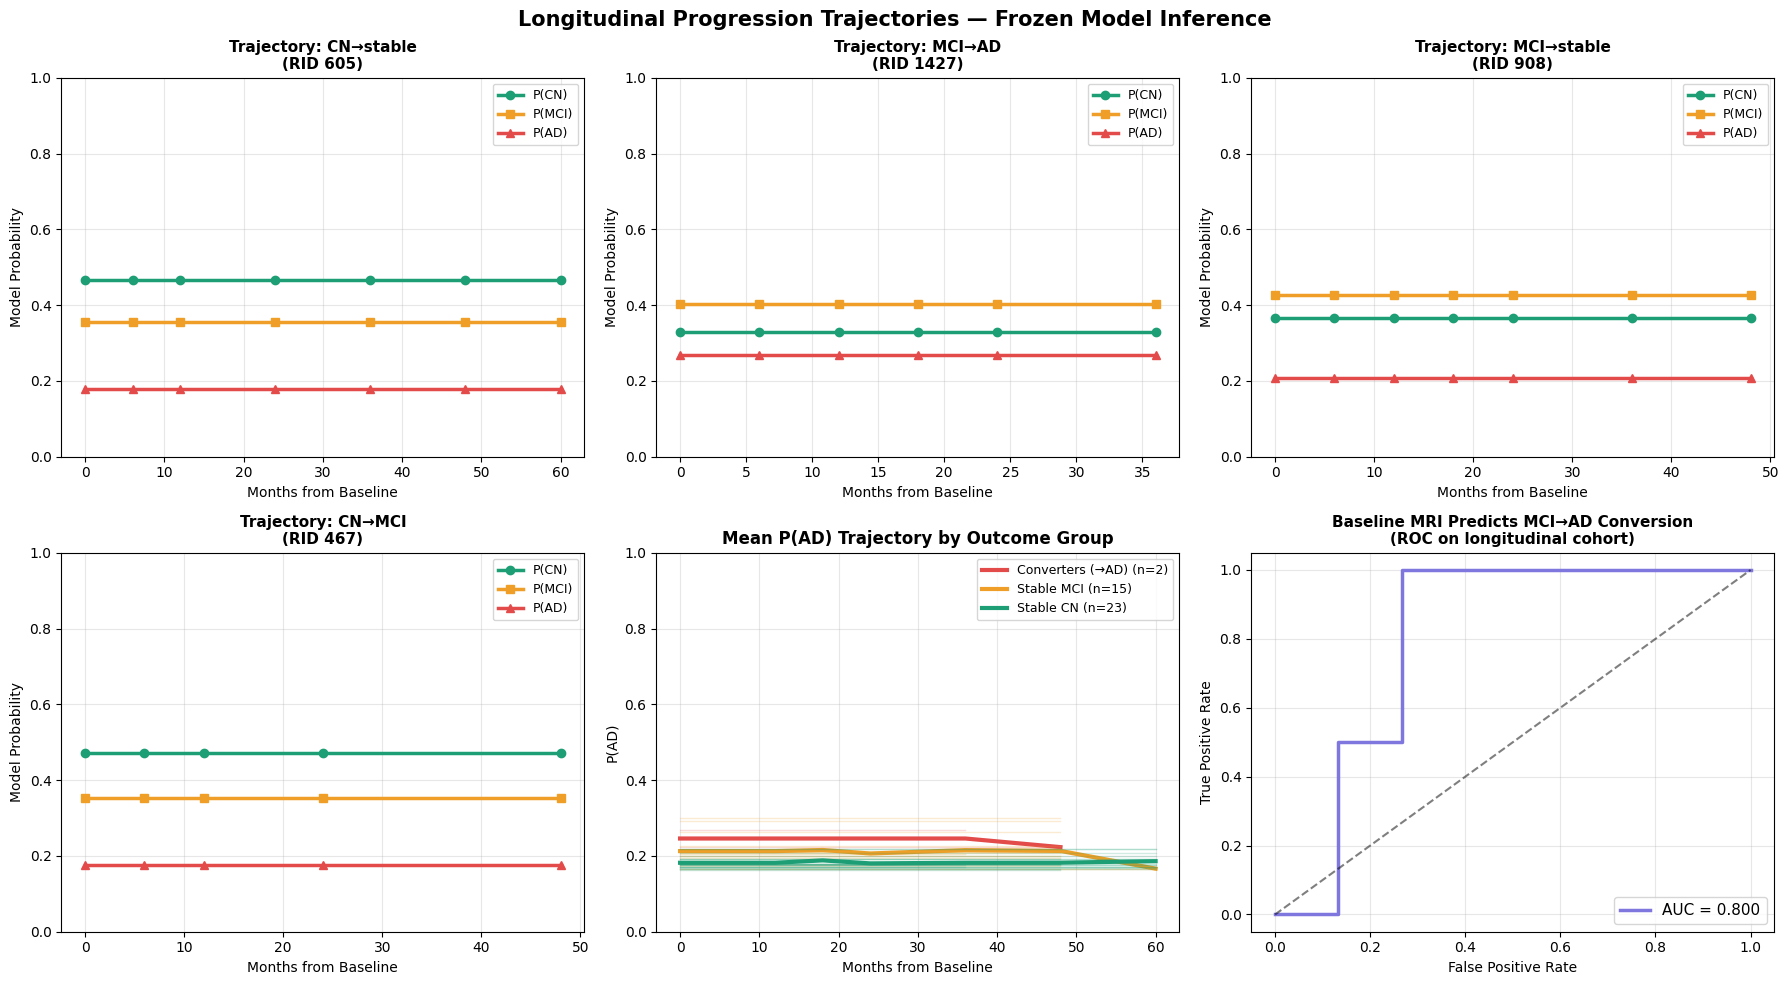


── Longitudinal Analysis Summary ──
Total subjects tracked: 40
  CN→stable: 21 subjects
  MCI→AD: 2 subjects
  MCI→stable: 13 subjects
  CN→MCI: 2 subjects


In [41]:
dxsum_long = load_rda("DXSUM.rda")
dxsum_long["RID"] = dxsum_long["RID"].astype(int)

viscode_to_months = {
    "bl": 0, "m06": 6, "m12": 12, "m18": 18,
    "m24": 24, "m36": 36, "m48": 48, "m60": 60,
    "sc": 0, "m03": 3
}

model.load_state_dict(torch.load(f"{CFG.output_dir}best_fold{best_fold_idx}.pth", map_location=DEVICE))
model.eval()

multi_visit_rids = dxsum_long["RID"].value_counts()
multi_visit_rids = multi_visit_rids[multi_visit_rids >= 3].index.tolist()

available_rids = set(
    int(sid.split("_S_")[1])
    for sid in manifest_clean["subject_id"]
    if "_S_" in sid
)
longitudinal_rids = [r for r in multi_visit_rids if r in available_rids]
print(f"Subjects with ≥3 visits AND MRI: {len(longitudinal_rids)}")

trajectories = []

for rid in longitudinal_rids[:40]: 
    visits = dxsum_long[dxsum_long["RID"] == rid].copy()
    visits["months"] = visits["VISCODE"].map(viscode_to_months)
    visits = visits.dropna(subset=["months", "DIAGNOSIS"]).sort_values("months")

    subj_rows = manifest_clean[
        manifest_clean["subject_id"].str.contains(f"_S_{rid:04d}", na=False)
    ]
    if subj_rows.empty:
        continue

    row = subj_rows.iloc[0]
    try:
        subj = tio.Subject(mri=tio.ScalarImage(row["preprocessed_path"]))
        vol  = F.interpolate(subj.mri.data.unsqueeze(0).float(),
                             size=CFG.target_shape, mode="trilinear", align_corners=False)
    except Exception:
        continue

    visit_records = []
    for _, vrow in visits.iterrows():
        mmse_val = row.get("mmse", np.nan)
        clinical = torch.tensor([
            float(row.get("age", 74.0)),
            1.0 if str(row.get("sex", "M")).upper() in ("M", "MALE") else 0.0,
            float(mmse_val) if not np.isnan(float(mmse_val if mmse_val else 0)) else 26.0,
            float(row.get("apoe4", 0.0)) if not np.isnan(float(row.get("apoe4", 0.0))) else 0.0,
        ], dtype=torch.float32)

        mean_c = torch.tensor([74.0, 0.5, 26.0, 0.3])
        std_c  = torch.tensor([7.0,  0.5,  3.5, 0.46])
        clinical = (clinical - mean_c) / (std_c + 1e-8)
        clinical = torch.nan_to_num(clinical, nan=0.0)

        with torch.no_grad():
            logits = model(vol.to(DEVICE), clinical.unsqueeze(0).to(DEVICE))
            probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

        visit_records.append({
            "months":   vrow["months"],
            "dx":       vrow["DIAGNOSIS"],
            "p_cn":     probs[0],
            "p_mci":    probs[1],
            "p_ad":     probs[2],
        })

    if len(visit_records) >= 2:
        trajectories.append({
            "rid":          rid,
            "visits":       visit_records,
            "final_dx":     visits.iloc[-1]["DIAGNOSIS"],
            "baseline_dx":  visits.iloc[0]["DIAGNOSIS"],
        })

print(f"Subjects with full trajectories: {len(trajectories)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

patterns = {
    "CN→stable":       [t for t in trajectories if t["baseline_dx"]=="CN"    and t["final_dx"]=="CN"],
    "MCI→AD":          [t for t in trajectories if t["baseline_dx"]=="MCI"   and t["final_dx"] in ("AD","Dementia")],
    "MCI→stable":      [t for t in trajectories if t["baseline_dx"]=="MCI"   and t["final_dx"]=="MCI"],
    "CN→MCI":          [t for t in trajectories if t["baseline_dx"]=="CN"    and t["final_dx"]=="MCI"],
}

for ax_idx, (pattern_name, group) in enumerate(patterns.items()):
    if not group or ax_idx >= 4:
        axes[ax_idx].axis("off")
        continue
    subj = group[0]
    months  = [v["months"] for v in subj["visits"]]
    p_cn    = [v["p_cn"]   for v in subj["visits"]]
    p_mci   = [v["p_mci"]  for v in subj["visits"]]
    p_ad    = [v["p_ad"]   for v in subj["visits"]]
    axes[ax_idx].plot(months, p_cn,  color="#1D9E75", lw=2.5, marker="o", label="P(CN)")
    axes[ax_idx].plot(months, p_mci, color="#EF9F27", lw=2.5, marker="s", label="P(MCI)")
    axes[ax_idx].plot(months, p_ad,  color="#E24B4A", lw=2.5, marker="^", label="P(AD)")
    axes[ax_idx].set_ylim(0, 1); axes[ax_idx].set_xlabel("Months from Baseline")
    axes[ax_idx].set_ylabel("Model Probability"); axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].set_title(f"Trajectory: {pattern_name}\n(RID {subj['rid']})",
                            fontsize=11, fontweight="bold")
    axes[ax_idx].grid(alpha=0.3)

ax5 = axes[4]
for final_dx, color, label in [
    (["AD", "Dementia"], "#E24B4A", "Converters (→AD)"),
    (["MCI"],            "#EF9F27", "Stable MCI"),
    (["CN"],             "#1D9E75", "Stable CN"),
]:
    group = [t for t in trajectories if t["final_dx"] in final_dx]
    if not group:
        continue
    all_months = sorted(set(v["months"] for t in group for v in t["visits"]))
    for t in group:
        m = [v["months"] for v in t["visits"]]
        p = [v["p_ad"]   for v in t["visits"]]
        ax5.plot(m, p, color=color, alpha=0.2, lw=1)
    month_probs = {mo: [] for mo in all_months}
    for t in group:
        for v in t["visits"]:
            month_probs[v["months"]].append(v["p_ad"])
    mo_mean = [(mo, np.mean(vals)) for mo, vals in month_probs.items() if vals]
    mo_mean.sort()
    ax5.plot([m for m,_ in mo_mean], [p for _,p in mo_mean],
             color=color, lw=3, label=f"{label} (n={len(group)})")
ax5.set_title("Mean P(AD) Trajectory by Outcome Group", fontsize=12, fontweight="bold")
ax5.set_xlabel("Months from Baseline"); ax5.set_ylabel("P(AD)")
ax5.legend(fontsize=9); ax5.grid(alpha=0.3); ax5.set_ylim(0, 1)

ax6 = axes[5]
converter_labels, converter_scores = [], []
for t in trajectories:
    if t["baseline_dx"] == "MCI" and len(t["visits"]) > 0:
        converted = 1 if t["final_dx"] in ("AD", "Dementia") else 0
        baseline_pad = t["visits"][0]["p_ad"]
        converter_labels.append(converted)
        converter_scores.append(baseline_pad)

if len(set(converter_labels)) == 2:
    from sklearn.metrics import roc_curve, auc as sk_auc
    fpr, tpr, _ = roc_curve(converter_labels, converter_scores)
    auc_conv    = sk_auc(fpr, tpr)
    ax6.plot(fpr, tpr, color="#7F77DD", lw=2.5, label=f"AUC = {auc_conv:.3f}")
    ax6.plot([0,1],[0,1],"k--",alpha=0.5)
    ax6.set_title("Baseline MRI Predicts MCI→AD Conversion\n(ROC on longitudinal cohort)",
                  fontsize=11, fontweight="bold")
    ax6.set_xlabel("False Positive Rate"); ax6.set_ylabel("True Positive Rate")
    ax6.legend(fontsize=11); ax6.grid(alpha=0.3)
    print(f"\nMCI→AD conversion prediction AUC (from baseline MRI): {auc_conv:.4f}")
else:
    ax6.text(0.5, 0.5, "Insufficient converter\nsamples in subset",
             ha="center", va="center", fontsize=13, transform=ax6.transAxes)
    ax6.axis("off")

plt.suptitle("Longitudinal Progression Trajectories — Frozen Model Inference",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG.output_dir + "longitudinal_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n── Longitudinal Analysis Summary ──")
print(f"Total subjects tracked: {len(trajectories)}")
for pattern_name, group in patterns.items():
    print(f"  {pattern_name}: {len(group)} subjects")

In [50]:
model.eval()

batch = next(iter(val_loader))

mri, clinical, labels = batch

mri = mri.to(device)
clinical = clinical.to(device)

print("MRI:", mri.shape)
print("Clinical:", clinical.shape)

MRI: torch.Size([8, 1, 96, 112, 96])
Clinical: torch.Size([8, 4])


In [56]:
import torch
import numpy as np

def counterfactual_analysis(model, mri, clinical, steps=5):
    model.eval()
    
    results = []
    base_pred = torch.softmax(model(mri, clinical), dim=1).detach().cpu().numpy()

    for i, name in enumerate(["Age", "Sex", "MMSE", "APOE4"]):
        vals = []

        std = clinical[:, i].std().item() + 1e-6 

        for delta in np.linspace(-1, 1, steps):
            clinical_cf = clinical.clone()
            clinical_cf[:, i] += delta * std  

            pred = torch.softmax(model(mri, clinical_cf), dim=1)
            vals.append(pred.detach().cpu().numpy())

        results.append(np.stack(vals))

    return base_pred, results

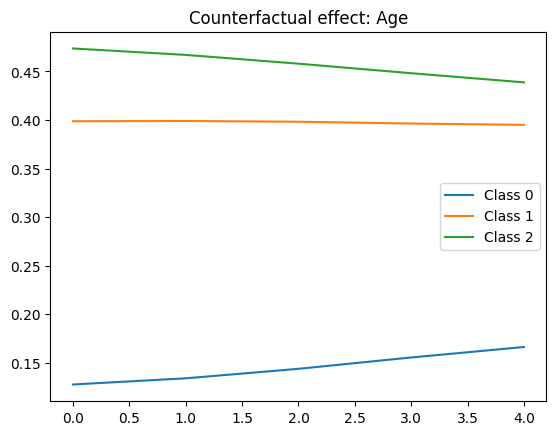

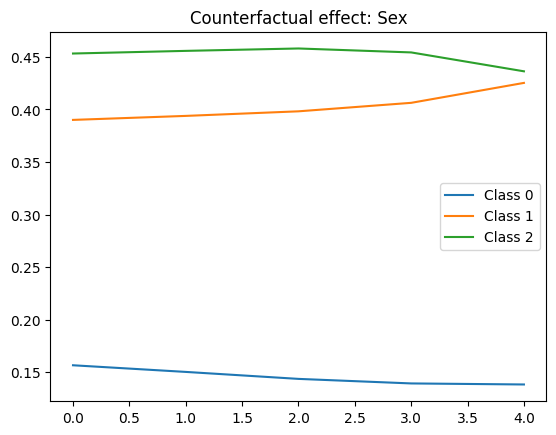

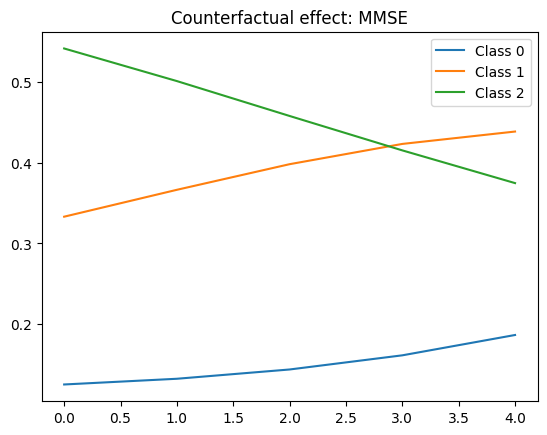

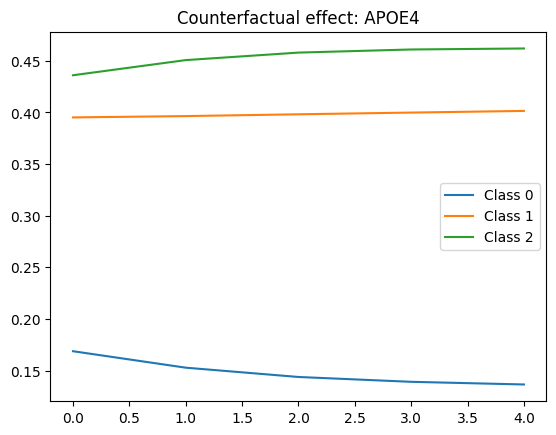

In [57]:
import matplotlib.pyplot as plt

base_pred, cf_results = counterfactual_analysis(model, mri, clinical)

feature_names = ["Age", "Sex", "MMSE", "APOE4"]

for i, name in enumerate(feature_names):
    plt.figure()
    for cls in range(3):
        plt.plot(cf_results[i][:, 0, cls], label=f"Class {cls}")
    plt.title(f"Counterfactual effect: {name}")
    plt.legend()
    plt.show()

In [61]:
import numpy as np

feature_names = ["Age", "Sex", "MMSE", "APOE4"]

sensitivities = []

for i, name in enumerate(feature_names):
    effect = np.abs(cf_results[i] - cf_results[i][0]).mean()
    sensitivities.append(effect)

for name, val in zip(feature_names, sensitivities):
    print(f"{name}: {val:.4f}")

Age: 0.0254
Sex: 0.0306
MMSE: 0.0659
APOE4: 0.0495


In [58]:
def enable_dropout(model):
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mc_dropout_predict(model, mri, clinical, T=20):
    model.eval()
    enable_dropout(model)

    preds = []

    for _ in range(T):
        out = torch.softmax(model(mri, clinical), dim=1)
        preds.append(out.detach().cpu().numpy())

    preds = np.stack(preds)
    mean = preds.mean(axis=0)
    std  = preds.std(axis=0)

    return mean, std

In [59]:
mean_pred, uncertainty = mc_dropout_predict(model, mri, clinical)

print("Prediction:", mean_pred)
print("Uncertainty:", uncertainty)

Prediction: [[0.13971868 0.41280085 0.4474805 ]
 [0.3545915  0.3727955  0.27261308]
 [0.29871264 0.42541486 0.27587253]
 [0.56463534 0.26932594 0.16603874]
 [0.33693776 0.49151024 0.17155193]
 [0.22683224 0.51513135 0.25803643]
 [0.2850609  0.41454306 0.30039605]
 [0.15232487 0.45821577 0.3894594 ]]
Uncertainty: [[0.02361595 0.0273802  0.03556106]
 [0.02749241 0.01855556 0.03333513]
 [0.03319051 0.03096018 0.0299762 ]
 [0.05278577 0.0310707  0.02795014]
 [0.03690429 0.03697031 0.03173883]
 [0.03074075 0.03326506 0.02142565]
 [0.02760855 0.0259958  0.02288859]
 [0.02219197 0.04203563 0.03783143]]


In [60]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_calibration(probs, labels):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    prob_true, prob_pred = calibration_curve(
        (predictions == labels),
        confidences,
        n_bins=5   
    )

    plt.figure(figsize=(5,5))
    plt.plot(prob_pred, prob_true, marker='o', label="Model")
    plt.plot([0,1],[0,1],'--', label="Perfect")

    plt.title("Calibration Curve")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

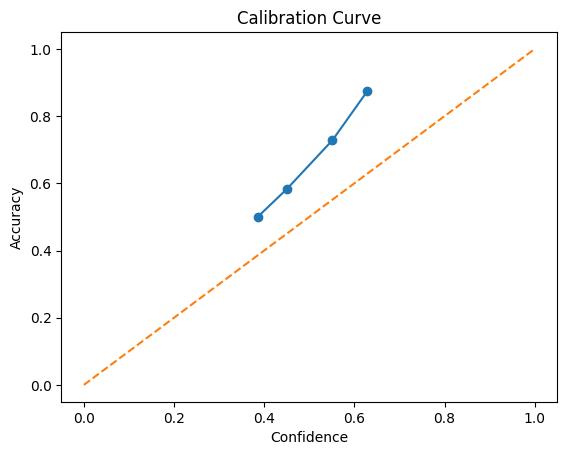

In [62]:
plot_calibration(all_probs, all_labels)

In [63]:
import torch.nn as nn

class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, mri, clinical):
        logits = self.model(mri, clinical)
        return logits / self.temperature

In [64]:
import torch
import torch.nn.functional as F

def set_temperature(model, val_loader, device):
    model.eval()
    temp_model = ModelWithTemperature(model).to(device)

    logits_list = []
    labels_list = []

    with torch.no_grad():
        for batch in val_loader:
            mri, clinical, labels = batch
            mri = mri.to(device)
            clinical = clinical.to(device)

            logits = model(mri, clinical)
            logits_list.append(logits)
            labels_list.append(labels.to(device))

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    optimizer = torch.optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

    def eval():
        optimizer.zero_grad()
        loss = F.cross_entropy(logits / temp_model.temperature, labels)
        loss.backward()
        return loss

    optimizer.step(eval)

    print("Optimal temperature:", temp_model.temperature.item())

    return temp_model

In [68]:
model.eval()

original_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        mri, clinical, labels = batch
        
        mri = mri.to(device)
        clinical = clinical.to(device)

        outputs = torch.softmax(model(mri, clinical), dim=1)

        original_probs.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

import numpy as np
original_probs = np.concatenate(original_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Original probs:", original_probs.shape)

Original probs: (194, 3)


In [69]:
temp_model = set_temperature(model, val_loader, device)

Optimal temperature: 0.8952429890632629


In [70]:
temp_model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        mri, clinical, labels = batch
        
        mri = mri.to(device)
        clinical = clinical.to(device)

        outputs = torch.softmax(temp_model(mri, clinical), dim=1)

        all_probs.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

import numpy as np
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

Before calibration:


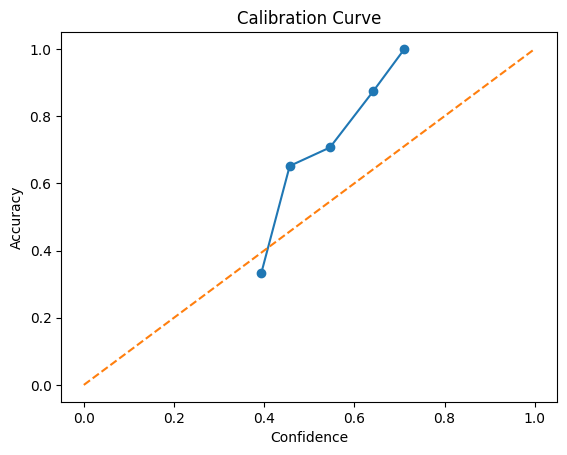

After calibration:


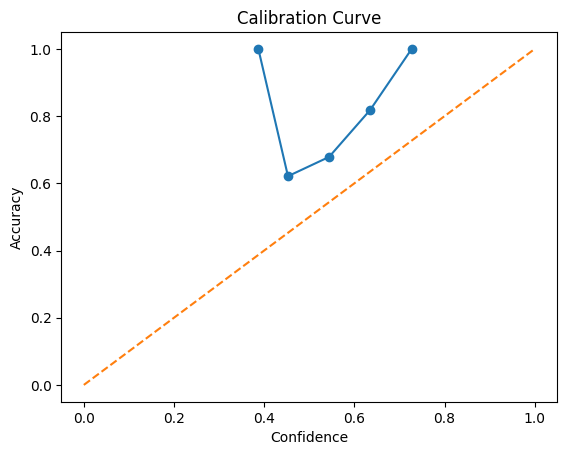

In [71]:
print("Before calibration:")
plot_calibration(original_probs, all_labels)

print("After calibration:")
plot_calibration(all_probs, all_labels)

In [72]:
def compute_ece(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if np.sum(mask) > 0:
            acc = accuracies[mask].mean()
            conf = confidences[mask].mean()
            ece += np.abs(acc - conf) * np.sum(mask) / len(probs)

    return ece

In [73]:
print("ECE before:", compute_ece(original_probs, all_labels))
print("ECE after :", compute_ece(all_probs, all_labels))

ECE before: 0.18584474445003824
ECE after : 0.16400446197421284


In [75]:
import numpy as np

def multiclass_brier_score(probs, labels):
    """
    probs: (N, C)
    labels: (N,)
    """
    n_classes = probs.shape[1]
    
    one_hot = np.eye(n_classes)[labels]
    
    return np.mean(np.sum((probs - one_hot) ** 2, axis=1))

In [77]:
from sklearn.metrics import brier_score_loss

brier_before = multiclass_brier_score(original_probs, all_labels)
brier_after  = multiclass_brier_score(all_probs, all_labels)

print("Brier before:", brier_before)
print("Brier after :", brier_after)

Brier before: 0.4691495477962161
Brier after : 0.4569175493249188


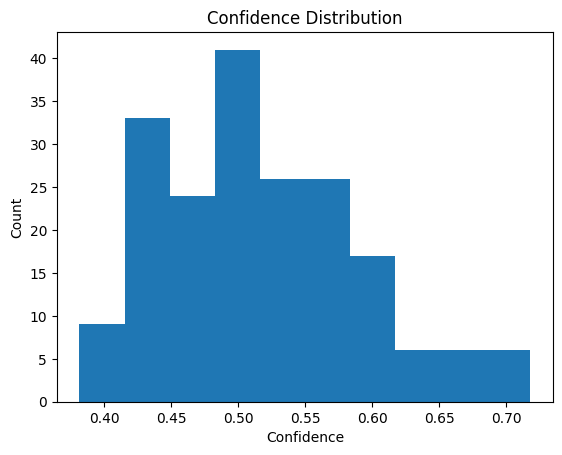

In [78]:
import matplotlib.pyplot as plt

conf = np.max(original_probs, axis=1)

plt.hist(conf, bins=10)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()